# FBI Crime Investigation

## Machine Learning Project: Time Series Forecasting

**Project Type:** Regression/Time-Series-Forecasting

**Contribution:** Team

**Team Member 1:** Muskaan Gaur

**Team Member 2:** Dhruv Gaur

## Project Summary

This project uses historical crime data from Vancouver (1999-2011) to build a model that predicts monthly crime counts across 9 crime categories. The dataset has ~474K records with features like crime type, location (lat/lon, neighbourhood), and timestamp.

The core problem is a time series regression: given past incident counts, predict how many crimes of each type will happen each month from Jan 2012 to Jun 2013 (162 predictions total).

**Approach:** Aggregate raw incident data to monthly counts per crime type, engineer lag and rolling features to capture temporal patterns, then compare XGBoost, Random Forest, and SARIMA. The best model is retrained on all available data before generating final predictions.

**Crime Types:** The 9 crime types are: Theft from Vehicle, Mischief, Break and Enter Commercial, Theft of Vehicle, Other Theft, Break and Enter Residential/Other, Offence Against a Person, Vehicle Collision or Pedestrian Struck, Theft of Bicycle.

**Business Impact:** Accurate crime forecasting enables law enforcement to allocate patrol resources efficiently, plan community policing initiatives, and optimize staffing schedules.

## GitHub Link

**Repository:** https://github.com/dhruvgaur10/Crime-Forecast-XGBoost

**Live Dashboard:** https://crime-forecast-xgboost.streamlit.app/

## Problem Statement

We have ~474K crime records from Vancouver covering 1999 to 2011. Each record has 13 features: TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, and Date.

**Task:** Predict the monthly Incident_Count for each of the 9 crime types from January 2012 through June 2013.

**Key Challenges:**
- Missing values in NEIGHBOURHOOD (~51K) and HOUR/MINUTE (~49K)
- Need to aggregate raw incident-level data to monthly counts
- Lag features must avoid data leakage
- Test predictions generated iteratively using previous month's forecasts

## General Guidelines

1. Well-structured, formatted, and commented code is required.
2. Exception handling and production-quality code will be evaluated.
3. All charts must have proper titles, labeled axes, and legends.
4. Each chart includes: Why, Insight, and Business Impact.
5. Every hypothesis includes statistical test, test statistic, and p-value.
6. The final model must be saved and submission file generated.

---
## 1. Know Your Data

### 1.1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import xgboost as xgb
import joblib
import os

### 1.1b Environment Setup

In [2]:
import os
import glob as glob_module

# Universal path detection - works on Local, Jupyter, and Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')

    # Try multiple possible paths in Google Drive
    possible_paths = [
        '/content/drive/My Drive/Module 6 project',
        '/content/drive/MyDrive/Module 6 project',
        '/content/drive/My Drive',
        '/content/drive/MyDrive'
    ]

    BASE = None
    for path in possible_paths:
        if os.path.exists(path) and os.path.exists(os.path.join(path, 'Train.xlsx')):
            BASE = path
            break

    # If still not found, search recursively
    if BASE is None:
        matches = glob_module.glob('/content/drive/**/Train.xlsx', recursive=True)
        if matches:
            BASE = os.path.dirname(os.path.abspath(matches[0]))

    if BASE is None:
        BASE = '/content/drive/My Drive'
        print("WARNING: Train.xlsx not found. Using My Drive as base.")

    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    current_dir = os.getcwd()
    BASE = None

    # Try current directory
    if os.path.exists('Train.xlsx'):
        BASE = os.getcwd()
    # Try parent directories
    elif os.path.exists('../Train.xlsx'):
        BASE = os.path.dirname(os.getcwd())
    elif os.path.exists('../../Train.xlsx'):
        BASE = os.path.dirname(os.path.dirname(os.getcwd()))
    else:
        # Recursive search
        matches = glob_module.glob('**/Train.xlsx', recursive=True)
        if matches:
            BASE = os.path.dirname(os.path.abspath(matches[0]))

    if BASE is None:
        BASE = os.getcwd()
        print("WARNING: Train.xlsx not found. Using current directory.")

    print("Running Locally/Jupyter")

print(f"BASE path: {BASE}")
print("Files available:")
print(f"  Train.xlsx: {os.path.exists(os.path.join(BASE, 'Train.xlsx'))}")
print(f"  Test.csv: {os.path.exists(os.path.join(BASE, 'Test.csv'))}")

Running Locally/Jupyter
BASE path: C:\Users\dhruv\Downloads\FBI's-Crime-Investigation
Files available:
  Train.xlsx: True
  Test.csv: True


In [3]:
train = pd.read_excel(f"{BASE}/Train.xlsx")
test  = pd.read_csv(f"{BASE}/Test.csv")
print(f" Train: {train.shape}  |  Test: {test.shape}")

 Train: (474565, 13)  |  Test: (162, 4)


In [4]:
train.tail()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
474560,Theft from Vehicle,E 28TH AVE / FRASER ST,Riley Park,493434.25,5454756.06,49.245542,-123.090211,19.0,0.0,2011,10,29,2011-10-29
474561,Theft from Vehicle,E 28TH AVE / FRASER ST,Riley Park,493434.25,5454756.06,49.245542,-123.090211,23.0,0.0,2011,3,9,2011-03-09
474562,Other Theft,23XX CAMBIE ST,Mount Pleasant,491656.42,5456901.55,49.264820,-123.114682,17.0,52.0,2011,2,10,2011-02-10
474563,Other Theft,7XX BUTE ST,West End,490797.66,5459282.31,49.286223,-123.126541,18.0,0.0,2011,12,20,2011-12-20
474564,Mischief,57XX MAIN ST,Sunset,492605.32,5453354.38,49.232924,-123.101574,18.0,30.0,2011,2,3,2011-02-03


In [5]:
test.head()

,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,NaN
1,2013,6,Theft of Vehicle,NaN
2,2013,6,Theft of Bicycle,NaN
3,2013,6,Theft from Vehicle,NaN
4,2013,6,Other Theft,NaN


### 1.4 Rows and Columns

In [6]:
print(f"Train : {train.shape[0]} rows x {train.shape[1]} cols")
print(f"Test  : {test.shape[0]} rows x {test.shape[1]} cols")
print(f"\nTrain cols: {list(train.columns)}")
print(f"Test  cols: {list(test.columns)}")

Train : 474565 rows x 13 cols
Test  : 162 rows x 4 cols

Train cols: ['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude', 'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date']
Test  cols: ['YEAR', 'MONTH', 'TYPE', 'Incident_Counts']


### 1.5 Data Info

In [7]:
train.info()
print()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  object        
 1   HUNDRED_BLOCK  474552 non-null  object        
 2   NEIGHBOURHOOD  423074 non-null  object        
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 47.1+ MB

<class 'pandas.core.frame.

### 1.6 Duplicate Check

In [8]:
print(f"Train duplicates : {train.duplicated().sum()}")
print(f"Test  duplicates : {test.duplicated().sum()}")

Train duplicates : 44618
Test  duplicates : 0


### 1.7 Missing Values

In [9]:
train_missing = train.isnull().sum()
train_missing_pct = (train.isnull().sum() / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': train_missing, 'Missing_Pct': train_missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)
print(f"\nTotal missing: {train.isnull().sum().sum()}")

               Missing_Count  Missing_Pct
NEIGHBOURHOOD          51491        10.85
HOUR                   49365        10.40
MINUTE                 49365        10.40
HUNDRED_BLOCK             13         0.00

Total missing: 150234


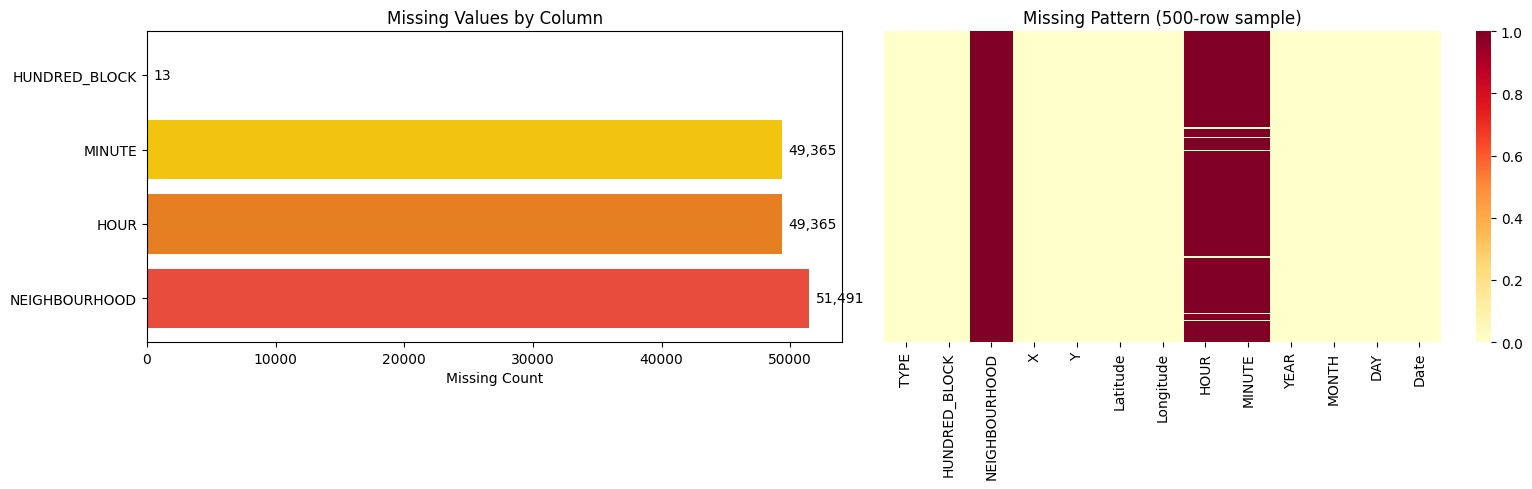

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_cols   = missing_df.index.tolist()
missing_counts = missing_df['Missing_Count'].values

axes[0].barh(missing_cols, missing_counts, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
axes[0].set_xlabel('Missing Count')
axes[0].set_title('Missing Values by Column')
for i, v in enumerate(missing_counts):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=10)

sample_idx = train[train.isnull().any(axis=1)].sample(
    min(500, train.isnull().any(axis=1).sum()), random_state=42).index
sns.heatmap(train.loc[sample_idx].isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Pattern (500-row sample)')

plt.tight_layout()
plt.show()

In [11]:
print("HOUR missing by crime type:")
print(train[train['HOUR'].isnull()]['TYPE'].value_counts())
print("\nNEIGHBOURHOOD missing by crime type:")
print(train[train['NEIGHBOURHOOD'].isnull()]['TYPE'].value_counts().head(10))

HOUR missing by crime type:
TYPE
Offence Against a Person    49365
Name: count, dtype: int64

NEIGHBOURHOOD missing by crime type:
TYPE
Offence Against a Person                                49365
Theft from Vehicle                                       1715
Mischief                                                  227
Theft of Bicycle                                          103
Theft of Vehicle                                           61
Vehicle Collision or Pedestrian Struck (with Injury)       10
Other Theft                                                 4
Break and Enter Residential/Other                           3
Break and Enter Commercial                                  3
Name: count, dtype: int64


**Missing Values Analysis:**

NEIGHBOURHOOD has the most missing values (~51K, ~10.7%). HOUR and MINUTE are missing ~49K times, almost entirely for Offence Against a Person. HUNDRED_BLOCK has only 13 missing entries.

Since the model aggregates to monthly counts, losing neighbourhood or time-of-day info doesn't affect the target variable directly.

---
## 2. Understanding Your Variables

### 2.1 Column Names and Data Types

In [12]:
print("Column overview:")
for col in train.columns:
    print(f"  {col:20s}  {str(train[col].dtype):12s}  non-null: {train[col].notna().sum():,}")

Column overview:
  TYPE                  object        non-null: 474,565
  HUNDRED_BLOCK         object        non-null: 474,552
  NEIGHBOURHOOD         object        non-null: 423,074
  X                     float64       non-null: 474,565
  Y                     float64       non-null: 474,565
  Latitude              float64       non-null: 474,565
  Longitude             float64       non-null: 474,565
  HOUR                  float64       non-null: 425,200
  MINUTE                float64       non-null: 425,200
  YEAR                  int64         non-null: 474,565
  MONTH                 int64         non-null: 474,565
  DAY                   int64         non-null: 474,565
  Date                  datetime64[ns]  non-null: 474,565


### 2.2 Descriptive Statistics

In [13]:
train.describe()

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000,474565
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253,2004-11-11 23:51:07.470209792
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000,1999-01-01 00:00:00
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000,2001-06-06 00:00:00
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000,2004-05-18 00:00:00
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000,2008-03-27 00:00:00
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000,2011-12-31 00:00:00
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352,NaN


In [14]:
train.describe(include='object')

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD
count,474565,474552,423074
unique,9,20566,24
top,Theft from Vehicle,OFFSET TO PROTECT PRIVACY,Central Business District
freq,153932,49365,96171


### 2.3 Variable Descriptions

| Variable | Description | Type |
|----------|-------------|------|
| TYPE | Crime category (9 unique types) | Categorical |
| HUNDRED_BLOCK | Approximate street address block | Categorical |
| NEIGHBOURHOOD | Vancouver neighbourhood name | Categorical |
| X | UTM Easting coordinate | Numerical |
| Y | UTM Northing coordinate | Numerical |
| Latitude | Geographic latitude | Numerical |
| Longitude | Geographic longitude | Numerical |
| HOUR | Hour of day the crime occurred (0-23) | Numerical |
| MINUTE | Minute the crime occurred (0-59) | Numerical |
| YEAR | Year of the crime (1999-2011) | Numerical |
| MONTH | Month of the crime (1-12) | Numerical |
| DAY | Day of month (1-31) | Numerical |
| Date | Full date of the crime | Datetime |

### 2.4 Unique Values

In [15]:
for col in train.columns:
    n = train[col].nunique()
    print(f"{col:20s} -> {n:,} unique")
    if n <= 15:
        print(f"  {sorted(train[col].dropna().unique())}")

TYPE                 -> 9 unique
  ['Break and Enter Commercial', 'Break and Enter Residential/Other', 'Mischief', 'Offence Against a Person', 'Other Theft', 'Theft from Vehicle', 'Theft of Bicycle', 'Theft of Vehicle', 'Vehicle Collision or Pedestrian Struck (with Injury)']
HUNDRED_BLOCK        -> 20,566 unique
NEIGHBOURHOOD        -> 24 unique
X                    -> 84,225 unique
Y                    -> 82,768 unique
Latitude             -> 89,488 unique
Longitude            -> 87,190 unique
HOUR                 -> 24 unique
MINUTE               -> 60 unique
YEAR                 -> 13 unique
  [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]
MONTH                -> 12 unique
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
DAY                  -> 31 unique
Date                 -> 4,748 unique


---
## 3. Data Wrangling

### 3.1 Handle Missing Values

In [16]:
train['HUNDRED_BLOCK'] = train['HUNDRED_BLOCK'].fillna('Unknown')
train['NEIGHBOURHOOD'] = train['NEIGHBOURHOOD'].fillna('Unknown')
train['HOUR']   = train['HOUR'].fillna(-1).astype(int)
train['MINUTE'] = train['MINUTE'].fillna(-1).astype(int)

print(f"Remaining nulls: {train.isnull().sum().sum()}")

Remaining nulls: 0


**Missing Value Strategy:**
- HUNDRED_BLOCK (13): filled with 'Unknown'
- NEIGHBOURHOOD (~51K): filled with 'Unknown'
- HOUR/MINUTE (~49K): filled with -1 as sentinel

No rows are dropped – all 474,565 records are kept.

---
## 4. Data Visualization (15 Charts)

### Chart 1: Crime Type Distribution
Theft from Vehicle dominates (32%), followed by Mischief (13%) and Other Theft (12%). Property crimes far outnumber violent offenses.

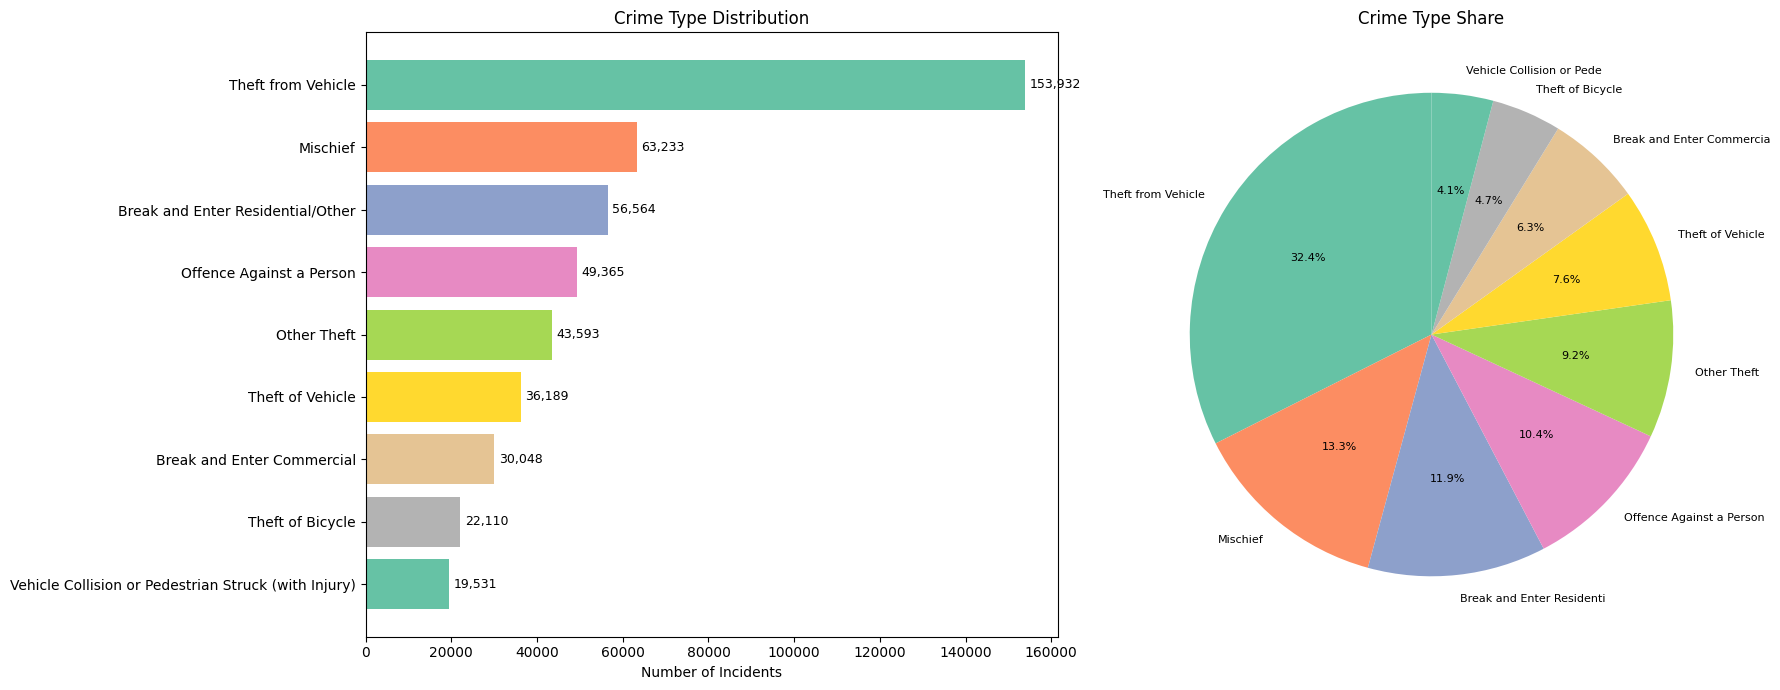

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
type_counts = train['TYPE'].value_counts()
colors = sns.color_palette('Set2', n_colors=len(type_counts))

bars = axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Number of Incidents')
axes[0].set_title('Crime Type Distribution')
for bar_item in bars:
    w = bar_item.get_width()
    axes[0].text(w + 1000, bar_item.get_y() + bar_item.get_height()/2,
                 f'{int(w):,}', va='center', fontsize=9)

axes[1].pie(type_counts.values, labels=[t[:25] for t in type_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Crime Type Share')

plt.tight_layout()
plt.show()

### Chart 2: Yearly Total Crime Trend
Crime declined 1999-2005, then stabilized. No sharp spikes or crashes in any year.

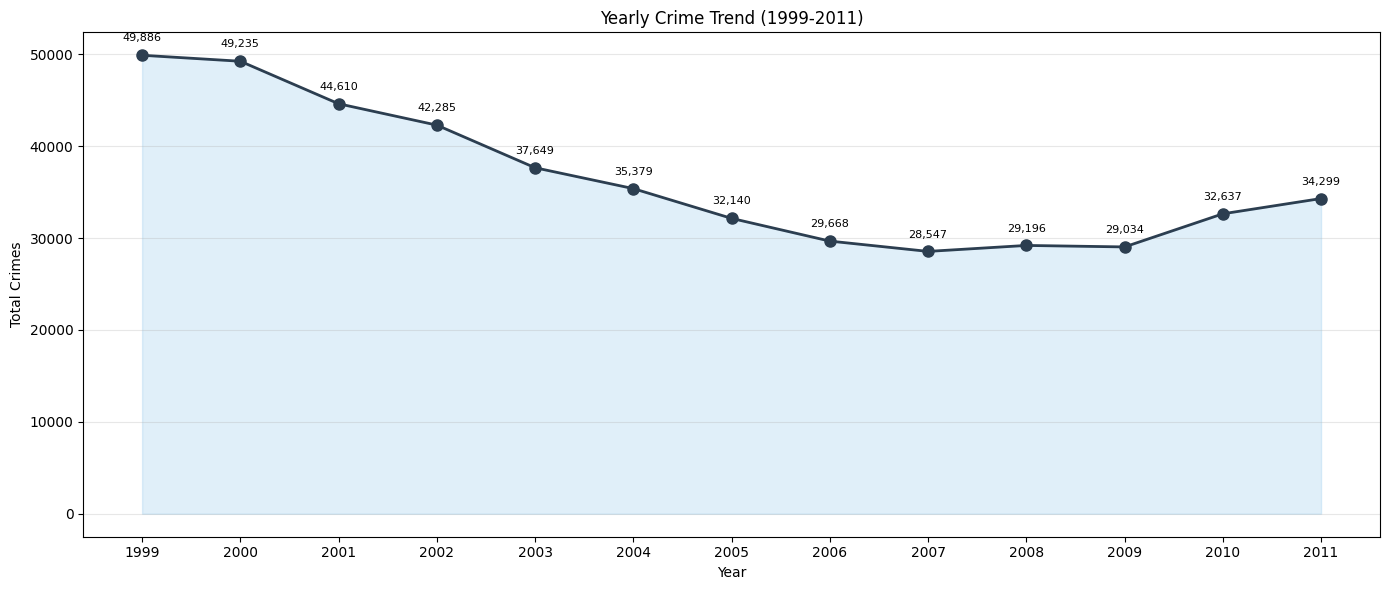

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
yearly_counts = train.groupby('YEAR').size().reset_index(name='Count')
ax.plot(yearly_counts['YEAR'], yearly_counts['Count'], marker='o', linewidth=2,
        color='#2c3e50', markersize=8)
ax.fill_between(yearly_counts['YEAR'], yearly_counts['Count'], alpha=0.15, color='#3498db')
ax.set_xlabel('Year'); ax.set_ylabel('Total Crimes')
ax.set_title('Yearly Crime Trend (1999-2011)')
ax.set_xticks(yearly_counts['YEAR'])
ax.grid(axis='y', alpha=0.3)

for _, row in yearly_counts.iterrows():
    ax.annotate(f"{int(row['Count']):,}", (row['YEAR'], row['Count']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### Chart 3: Yearly Trends by Crime Type
Theft from Vehicle and Theft of Vehicle declined 1999-2005, then stabilized. Theft of Bicycle grew steadily as cycling became popular.

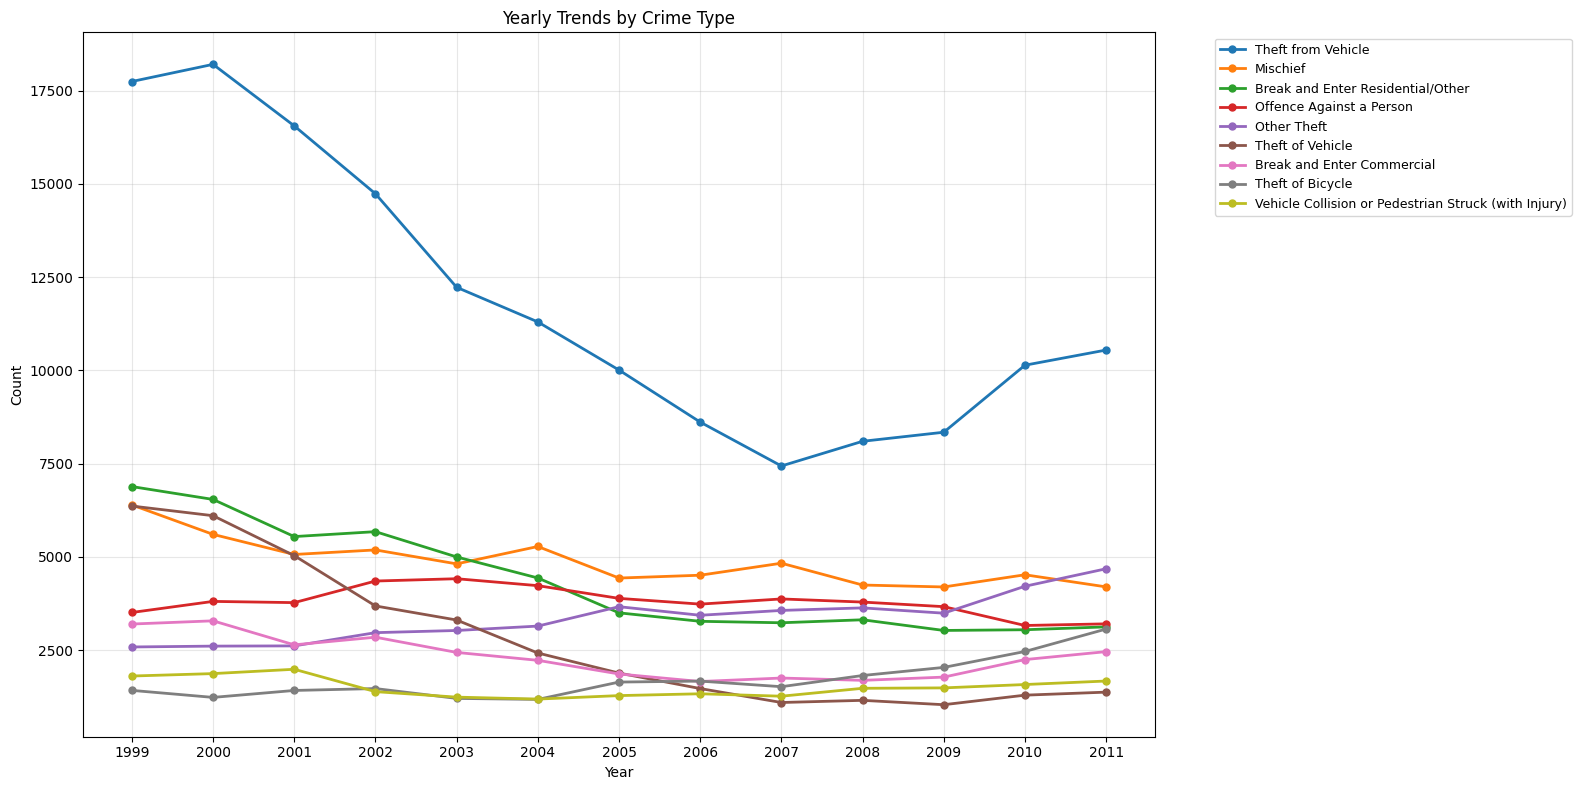

In [19]:
fig, ax = plt.subplots(figsize=(16, 8))
yearly_type = train.groupby(['YEAR', 'TYPE']).size().reset_index(name='Count')
for crime_type in type_counts.index:
    subset = yearly_type[yearly_type['TYPE'] == crime_type]
    ax.plot(subset['YEAR'], subset['Count'], marker='o', linewidth=2,
            label=crime_type, markersize=5)

ax.set_xlabel('Year'); ax.set_ylabel('Count')
ax.set_title('Yearly Trends by Crime Type')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3); ax.set_xticks(range(1999, 2012))
plt.tight_layout()
plt.show()

### Chart 4: Monthly Seasonality
June, July, August peak (15-20% higher). December, January lowest. Strong seasonal pattern.

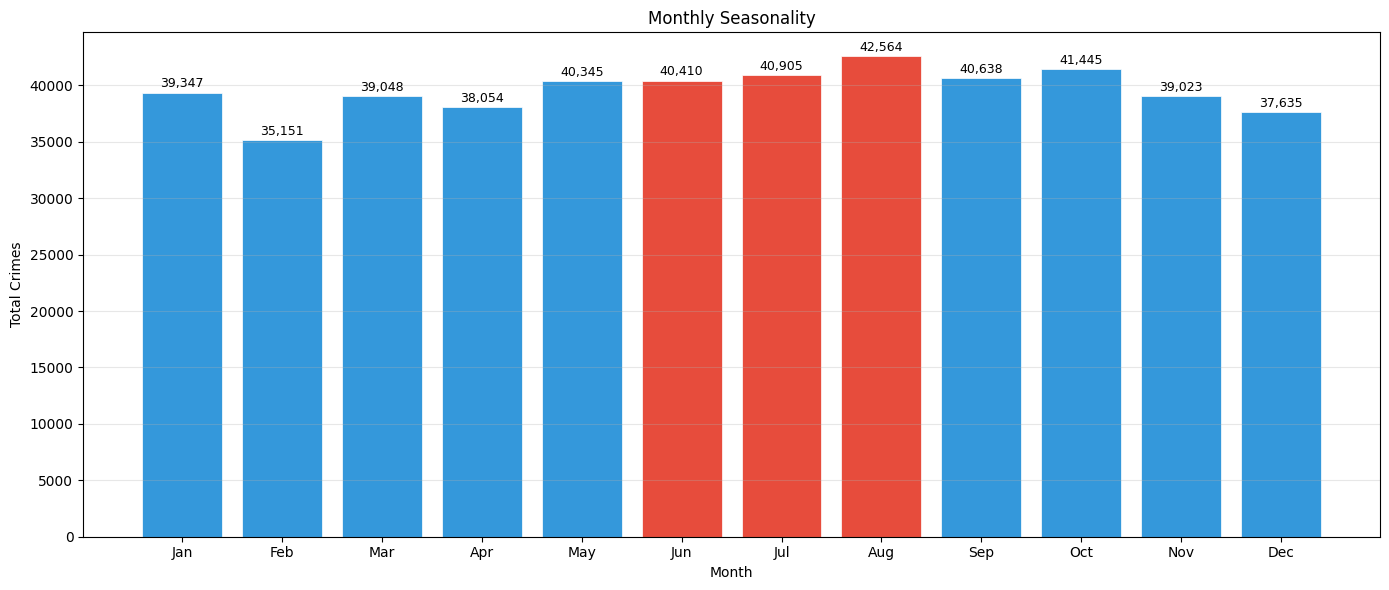

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
monthly_counts = train.groupby('MONTH').size().reset_index(name='Count')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = ['#e74c3c' if m in [6,7,8] else '#3498db' for m in range(1,13)]

bars = ax.bar(monthly_counts['MONTH'], monthly_counts['Count'], color=bar_colors,
              edgecolor='white', linewidth=0.5)
ax.set_xlabel('Month'); ax.set_ylabel('Total Crimes')
ax.set_title('Monthly Seasonality')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., h + 200, f'{int(h):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Chart 5: Monthly Trends by Crime Type
Theft of Bicycle most seasonal (summer spike, winter low). Offence Against a Person flat.

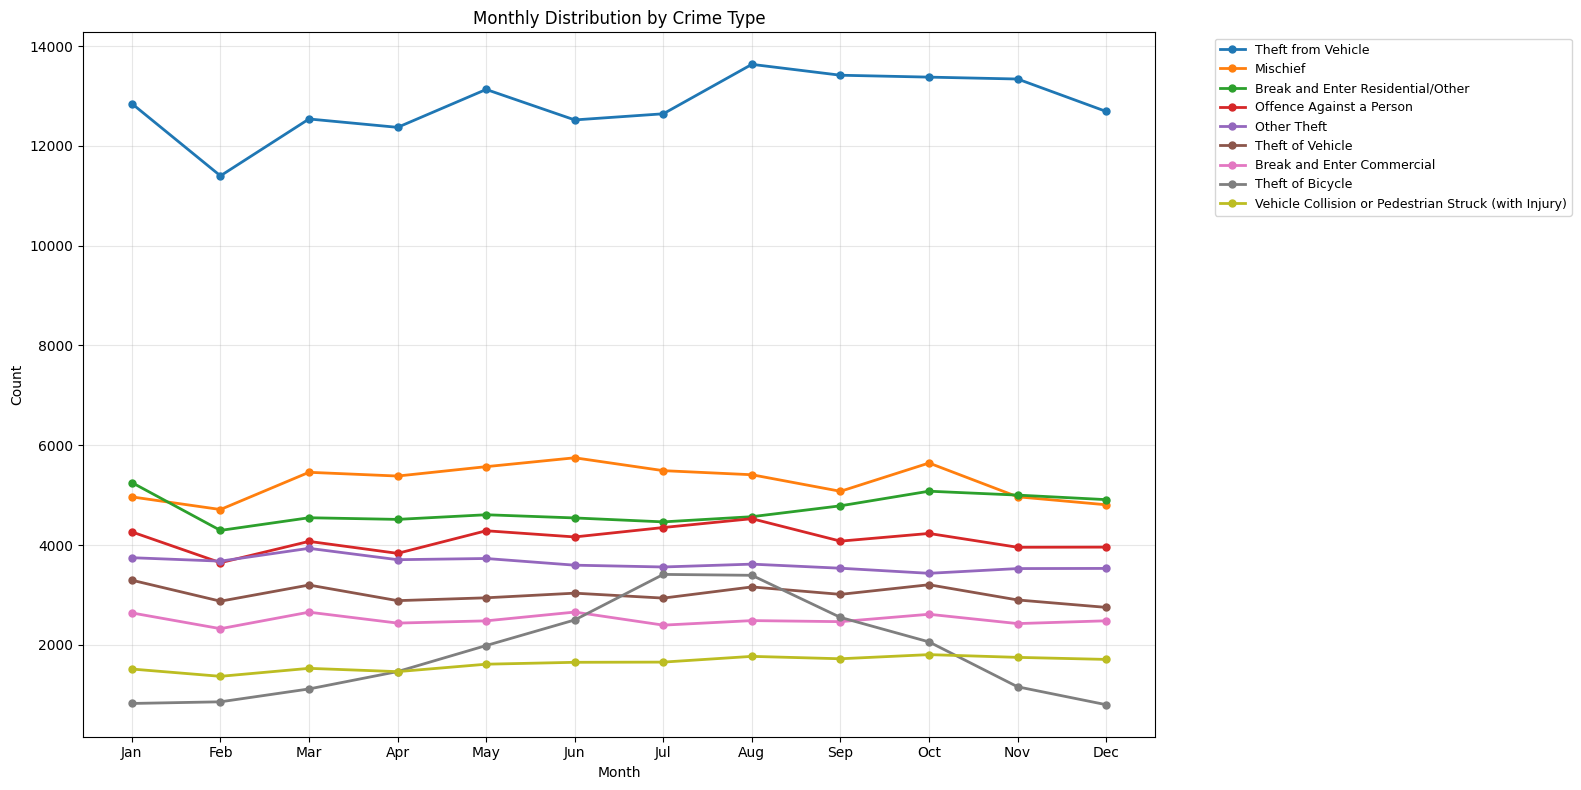

In [21]:
fig, ax = plt.subplots(figsize=(16, 8))
monthly_type = train.groupby(['MONTH', 'TYPE']).size().reset_index(name='Count')
for crime_type in type_counts.index:
    subset = monthly_type[monthly_type['TYPE'] == crime_type]
    ax.plot(subset['MONTH'], subset['Count'], marker='o', linewidth=2, label=crime_type, markersize=5)

ax.set_xlabel('Month'); ax.set_ylabel('Count')
ax.set_title('Monthly Distribution by Crime Type')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 6: Hourly Crime Heatmap
Property crimes cluster evening (18:00-23:00). Collisions peak at commute hours. Mischief late night.

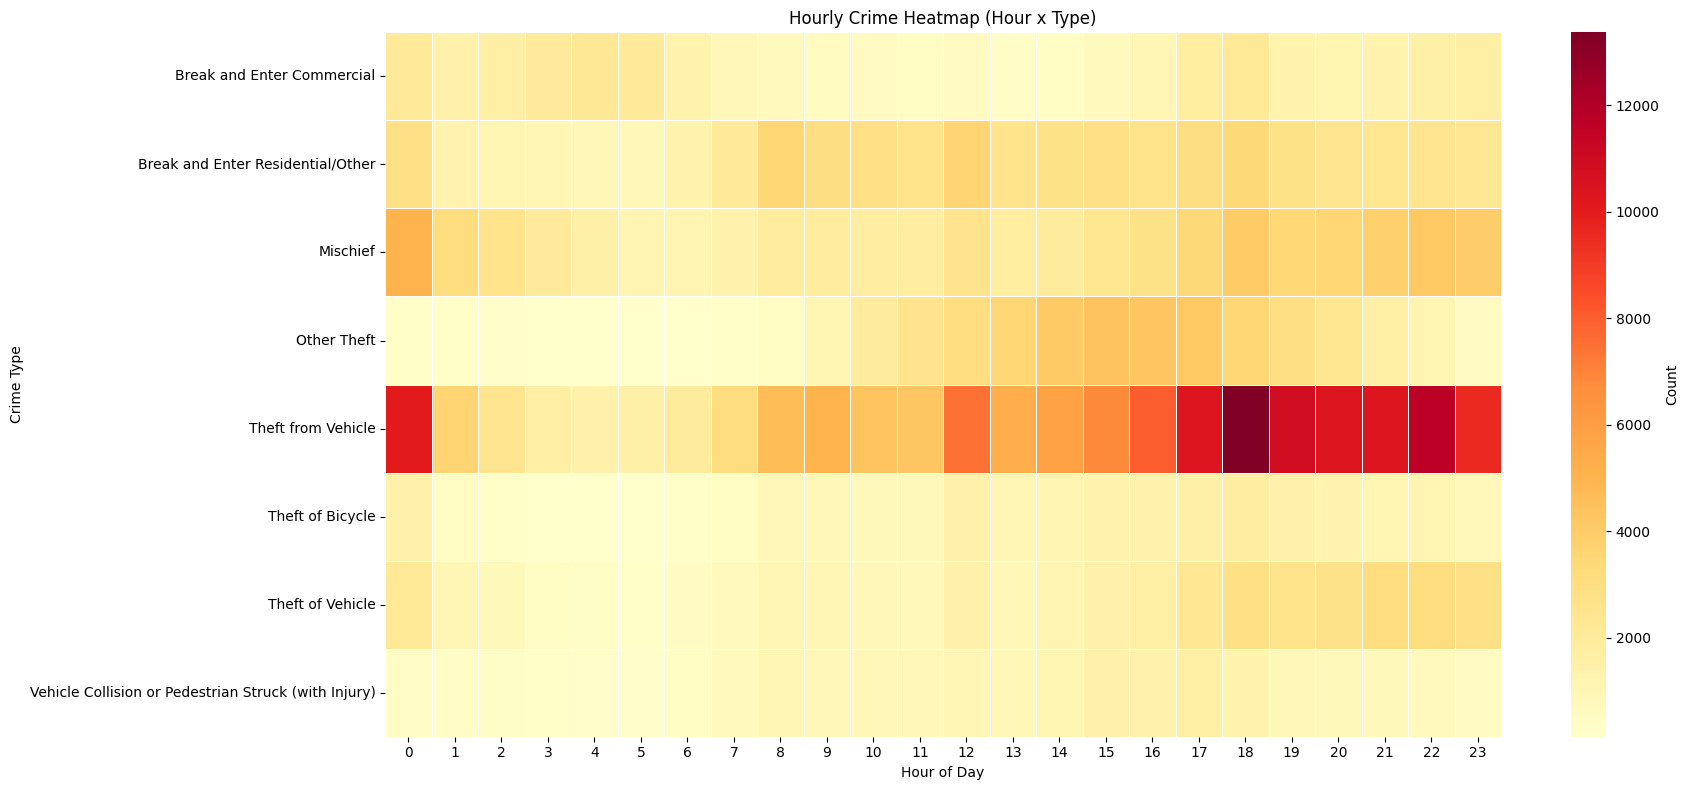

In [22]:
fig, ax = plt.subplots(figsize=(18, 8))
hourly_data = train[train['HOUR'] >= 0]
hourly_type = hourly_data.groupby(['HOUR', 'TYPE']).size().reset_index(name='Count')
heatmap_data = hourly_type.pivot(index='TYPE', columns='HOUR', values='Count').fillna(0)

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Hourly Crime Heatmap (Hour x Type)')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Crime Type')
plt.tight_layout()
plt.show()

### Chart 7: Top 15 Neighbourhoods
Central Business District dominates (5x other areas). West End, Mount Pleasant, Kitsilano follow.

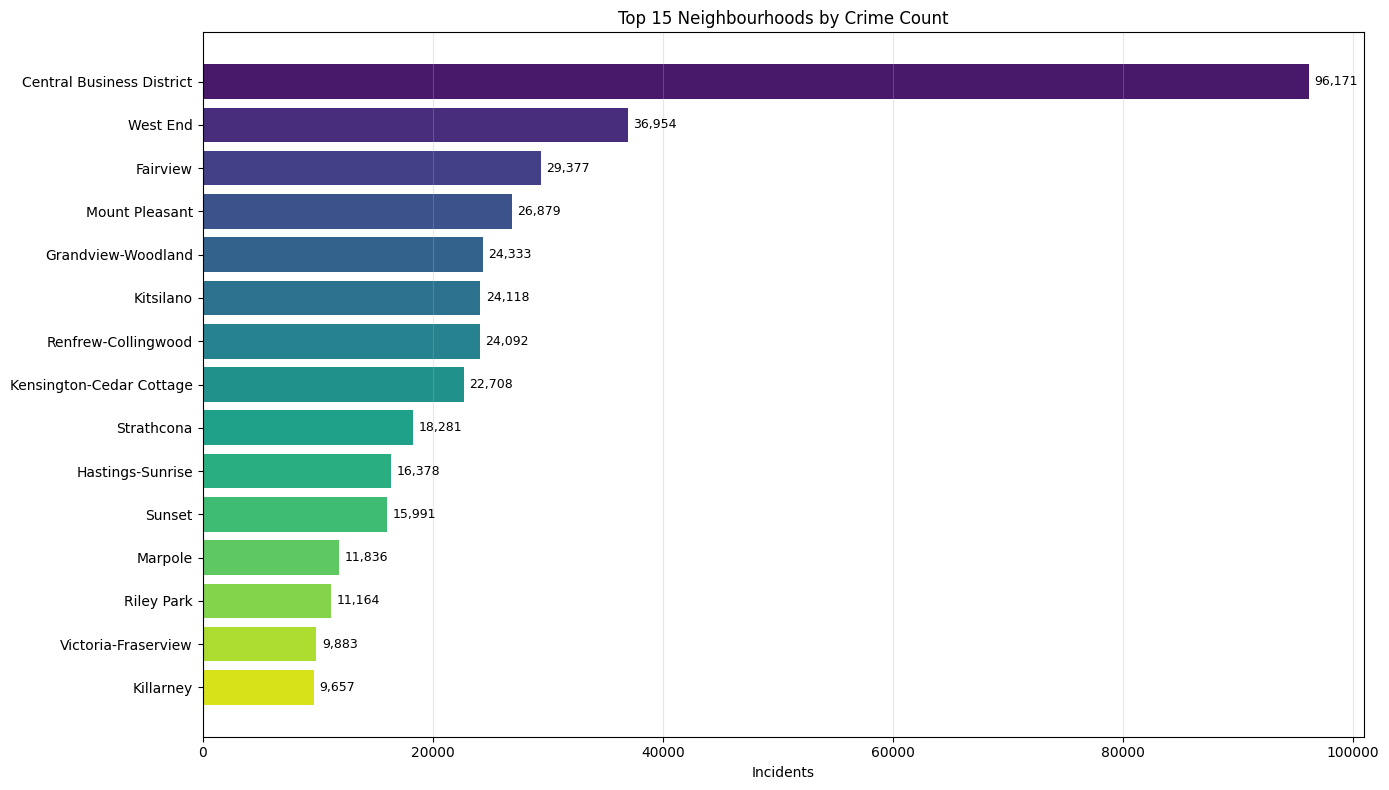

In [23]:
fig, ax = plt.subplots(figsize=(14, 8))
neighbourhood_counts = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
                        .value_counts().head(15))
colors_nb = sns.color_palette('viridis', n_colors=15)

bars = ax.barh(neighbourhood_counts.index[::-1], neighbourhood_counts.values[::-1], color=colors_nb[::-1])
ax.set_xlabel('Incidents'); ax.set_title('Top 15 Neighbourhoods by Crime Count')

for b in bars:
    w = b.get_width()
    ax.text(w + 500, b.get_y() + b.get_height()/2, f'{int(w):,}', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 8: Spatial Scatter Plot
Downtown Vancouver is the densest crime cluster. Secondary clusters along commercial corridors.

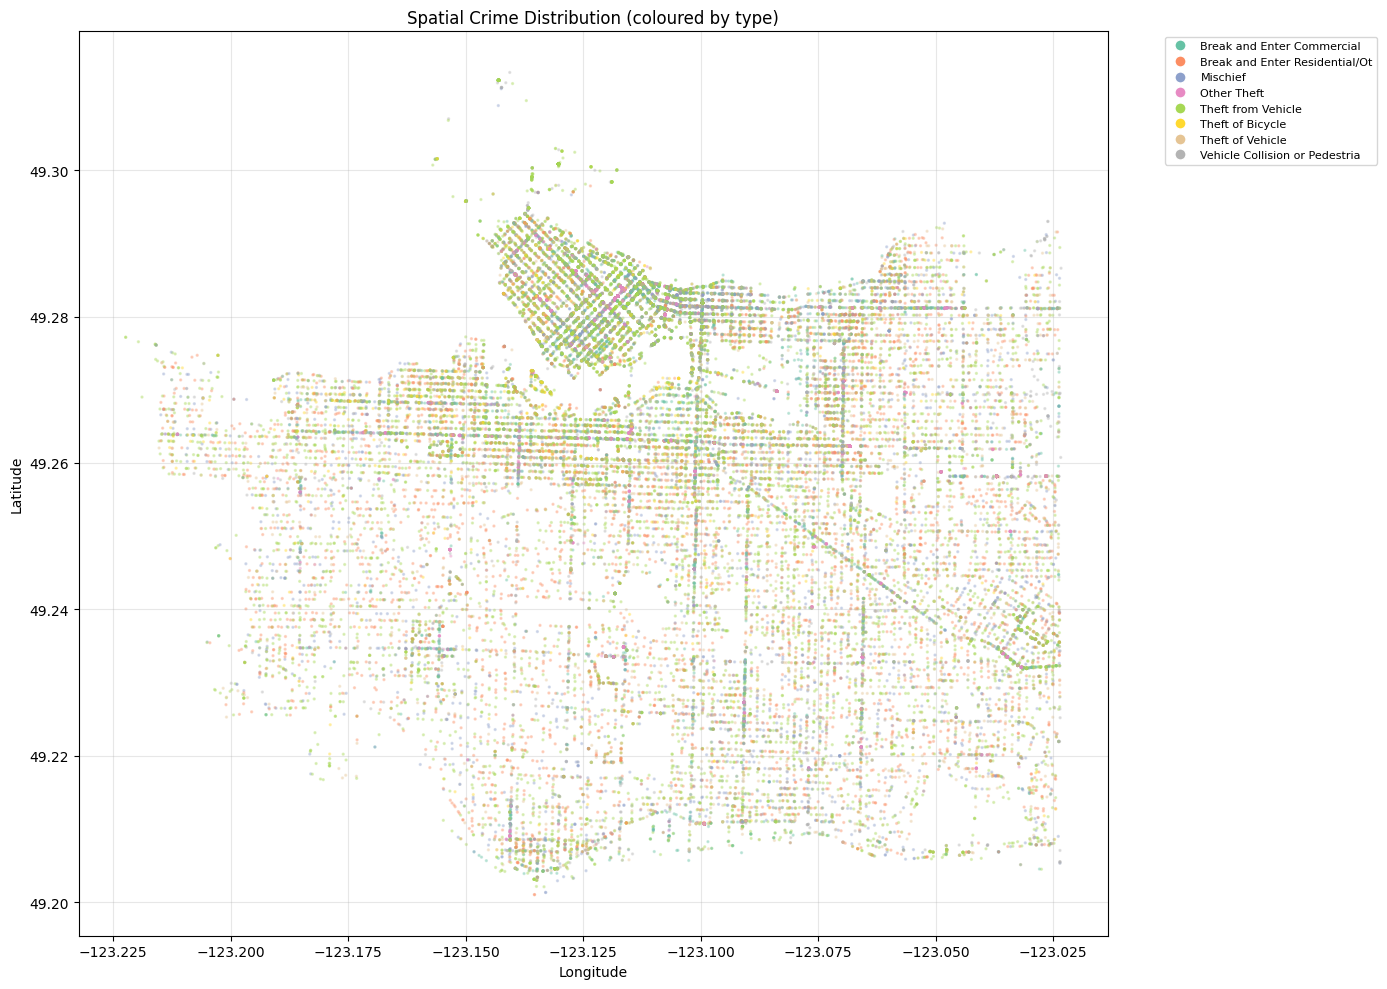

In [24]:
fig, ax = plt.subplots(figsize=(14, 10))
sample = train.sample(min(50000, len(train)), random_state=42)
sample_valid = sample[(sample['Latitude'] != 0) & (sample['Longitude'] != 0)]

ax.scatter(sample_valid['Longitude'], sample_valid['Latitude'],
           c=sample_valid['TYPE'].astype('category').cat.codes, cmap='Set2', alpha=0.3, s=2)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Spatial Crime Distribution (coloured by type)')

crime_types_list = sample_valid['TYPE'].astype('category').cat.categories.tolist()
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=plt.cm.Set2(i/len(crime_types_list)),
           markersize=8, label=ct[:30]) for i, ct in enumerate(crime_types_list)]
ax.legend(handles=handles, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 8b: GeoPandas Crime Density
Downtown appears as solid dark region. Confirms spatial concentration.

In [25]:
try:
    import geopandas as gpd
    from shapely.geometry import Point
    geo_train = train[(train['Latitude'] != 0) & (train['Longitude'] != 0)].copy()
    geometry = [Point(xy) for xy in zip(geo_train['Longitude'], geo_train['Latitude'])]
    gdf = gpd.GeoDataFrame(geo_train, geometry=geometry, crs='EPSG:4326')
    nb_counts = (gdf[gdf['NEIGHBOURHOOD'] != 'Unknown'].groupby('NEIGHBOURHOOD').size().reset_index(name='Crime_Count'))
    nb_hulls = (gdf[gdf['NEIGHBOURHOOD'] != 'Unknown'].groupby('NEIGHBOURHOOD')['geometry']
                .apply(lambda g: g.unary_union.convex_hull).reset_index())
    nb_hulls.columns = ['NEIGHBOURHOOD', 'geometry']
    nb_gdf = gpd.GeoDataFrame(nb_hulls.merge(nb_counts, on='NEIGHBOURHOOD'), geometry='geometry', crs='EPSG:4326')
    fig, ax = plt.subplots(figsize=(14, 10))
    nb_gdf.plot(column='Crime_Count', cmap='YlOrRd', legend=True,
                legend_kwds={'label': 'Crime Count', 'orientation': 'vertical'},
                edgecolor='grey', linewidth=0.4, alpha=0.8, ax=ax)
    ax.set_title('Crime Density by Neighbourhood (GeoPandas Choropleth)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"GeoDataFrame built: {nb_gdf.shape[0]} neighbourhoods plotted.")
except ImportError:
    print("geopandas not installed.")

geopandas not installed.


### Chart 9: Day of Week Distribution
Fairly consistent across weekdays. Friday/Saturday slightly higher. Weekly pattern weak.

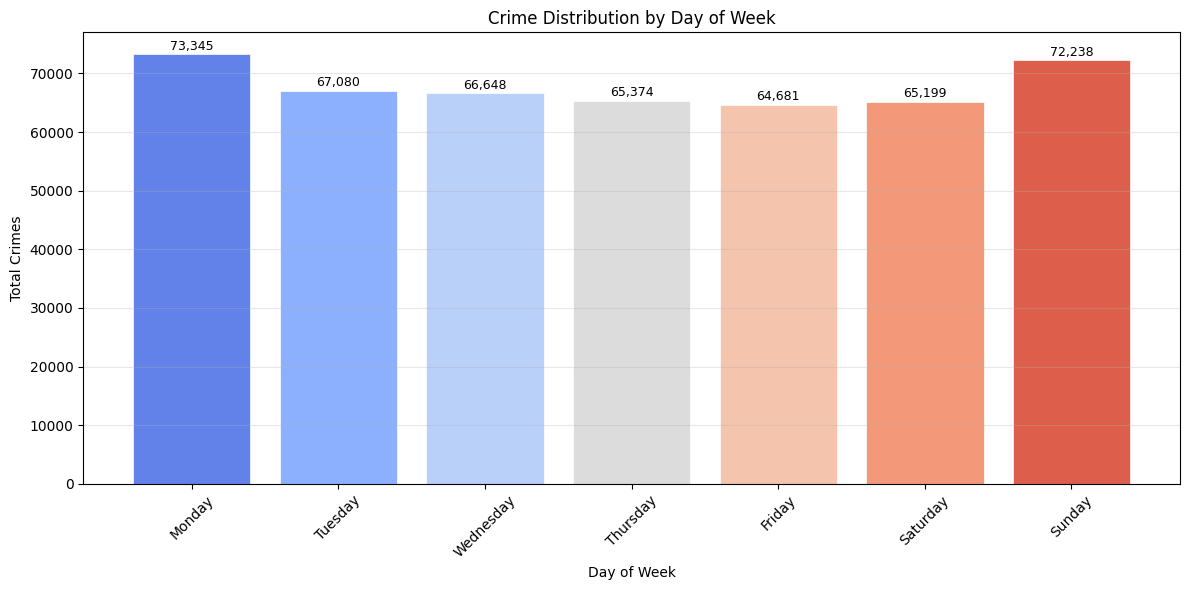

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
train['Date'] = pd.to_datetime(train['Date'], errors='coerce')
train['DAY_OF_WEEK'] = train['Date'].dt.dayofweek
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = train['DAY_OF_WEEK'].value_counts().sort_index()

bars = ax.bar(range(7), day_counts.values, color=sns.color_palette('coolwarm', 7),
              edgecolor='white', linewidth=0.5)
ax.set_xticks(range(7)); ax.set_xticklabels(day_names, rotation=45)
ax.set_xlabel('Day of Week'); ax.set_ylabel('Total Crimes')
ax.set_title('Crime Distribution by Day of Week')
ax.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., h + 200, f'{int(h):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Chart 10: Crime Type Composition in Top 5 Neighbourhoods
CBD: heavy Theft from Vehicle/Mischief. Residential areas: more Break and Enter Residential.

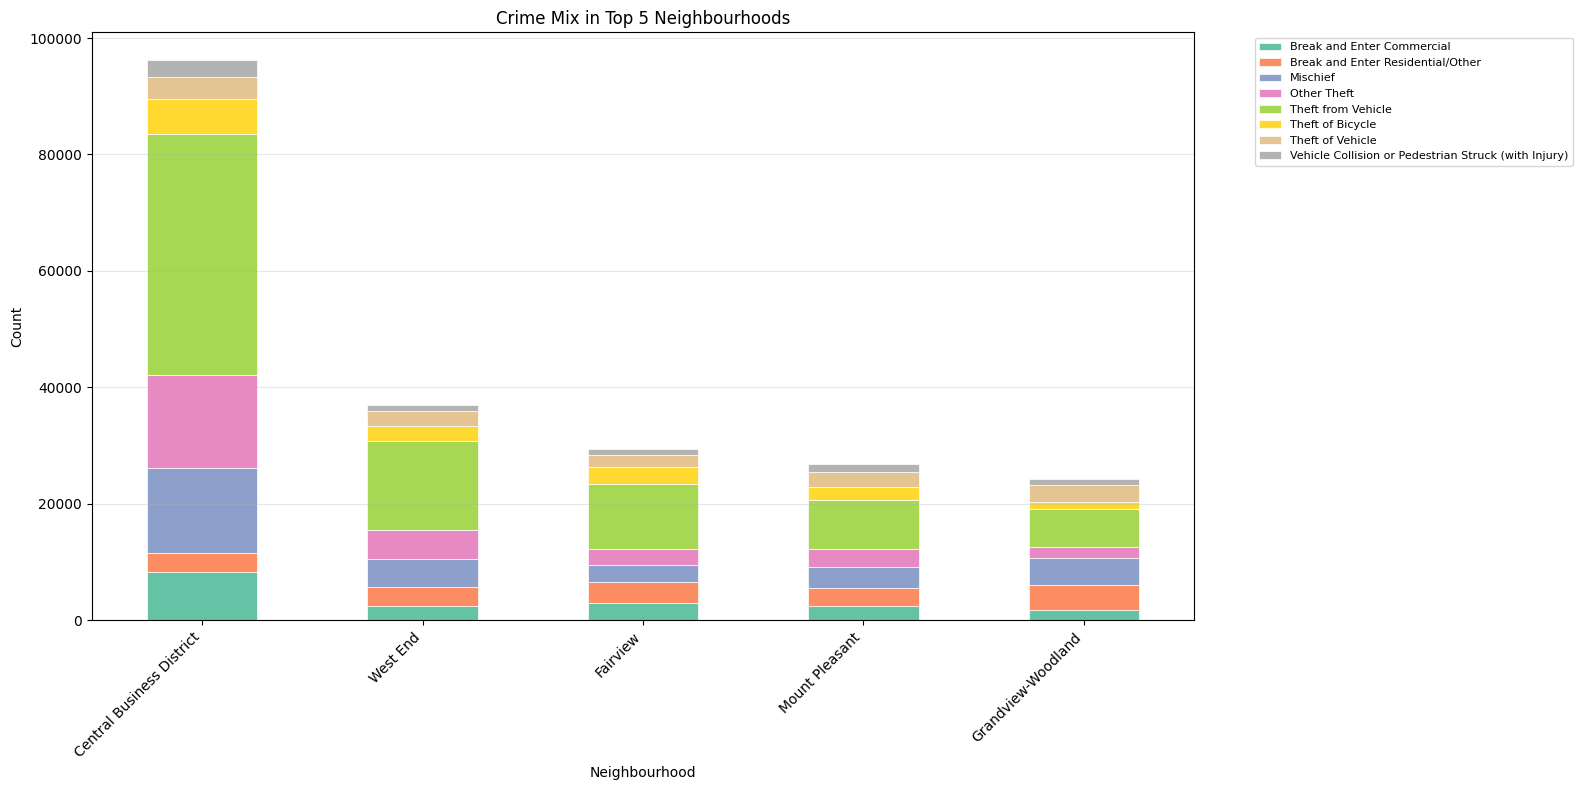

In [27]:
fig, ax = plt.subplots(figsize=(16, 8))
top5_nb = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD'].value_counts().head(5).index.tolist())
top5_data = train[train['NEIGHBOURHOOD'].isin(top5_nb)]
crosstab = pd.crosstab(top5_data['NEIGHBOURHOOD'], top5_data['TYPE'])
crosstab.loc[top5_nb].plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Neighbourhood'); ax.set_ylabel('Count')
ax.set_title('Crime Mix in Top 5 Neighbourhoods')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 11: Hourly Distribution Violin Plot
Most crimes widely spread across hours. Theft from Vehicle skewed toward evening. Collisions symmetric.

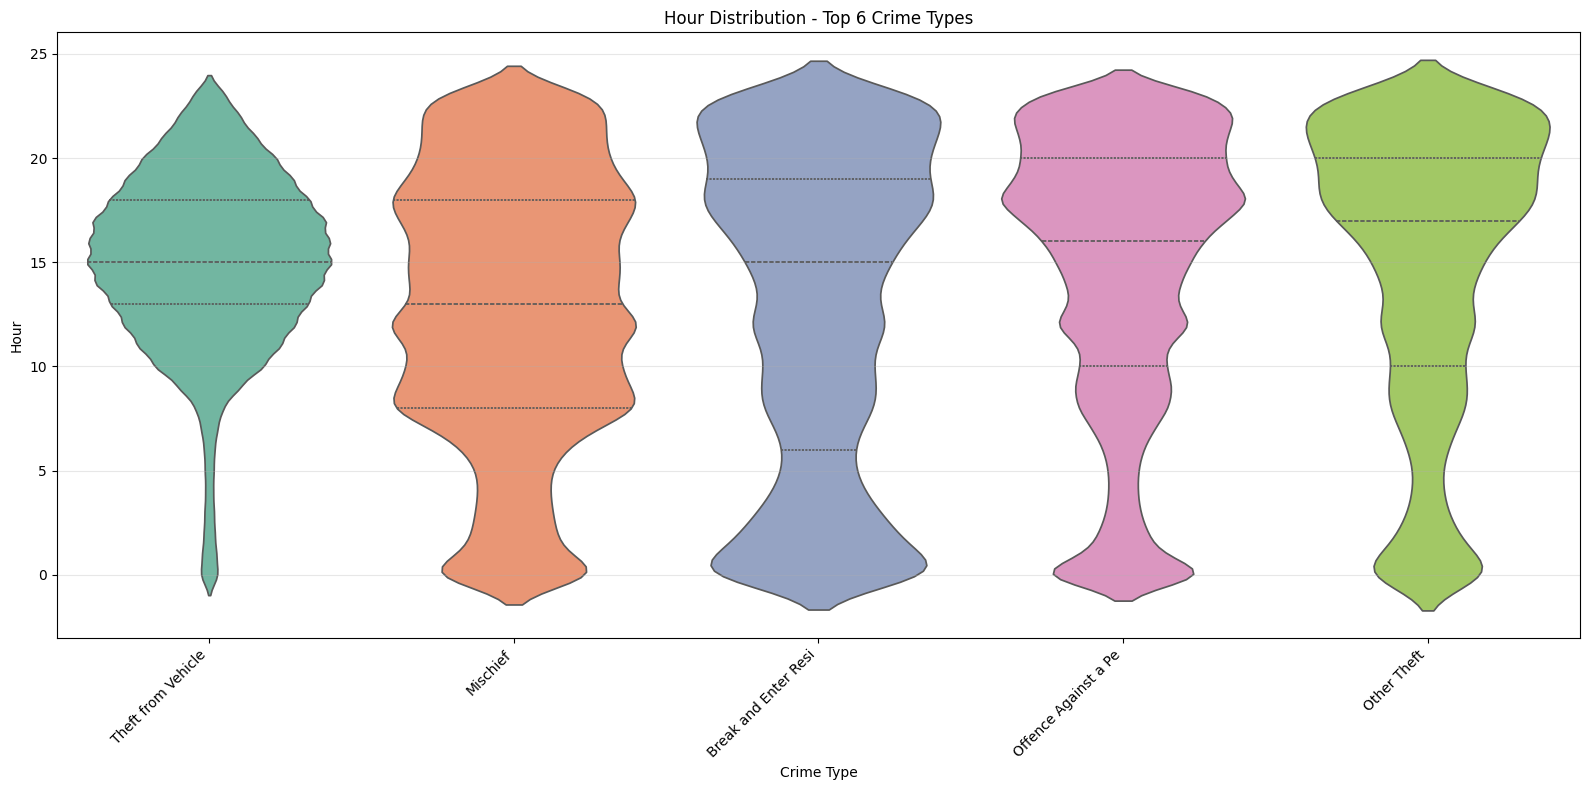

In [28]:
fig, ax = plt.subplots(figsize=(16, 8))
hourly_valid = train[train['HOUR'] >= 0][['TYPE', 'HOUR']]
top6_types = type_counts.index[:6].tolist()
hourly_top6 = hourly_valid[hourly_valid['TYPE'].isin(top6_types)]
sns.violinplot(x='TYPE', y='HOUR', data=hourly_top6, palette='Set2', inner='quartile', ax=ax)
ax.set_xticklabels([t[:20] for t in top6_types], rotation=45, ha='right')
ax.set_xlabel('Crime Type'); ax.set_ylabel('Hour')
ax.set_title('Hour Distribution - Top 6 Crime Types')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 12: Year x Month Heatmap
Summer peaks (months 6-8) consistent across all 13 years. Pattern stable, no anomalies.

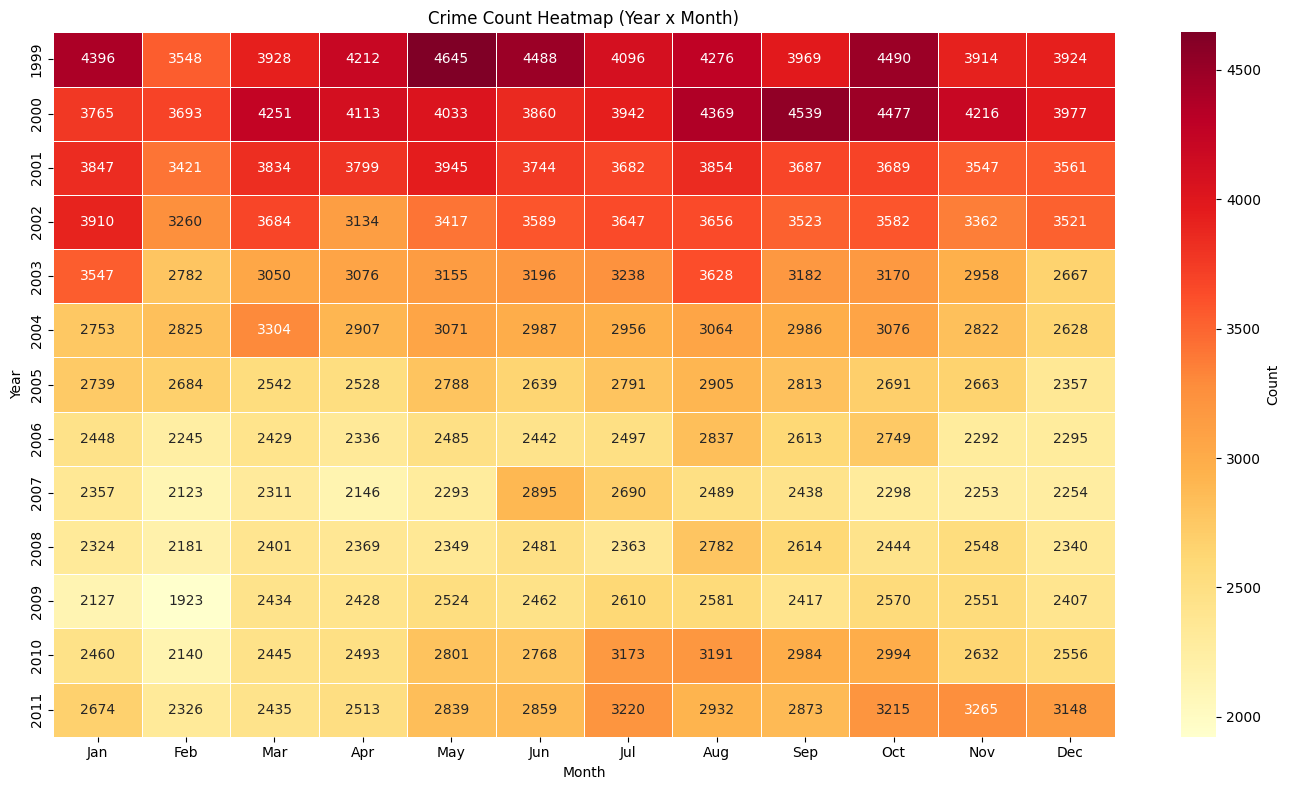

In [29]:
fig, ax = plt.subplots(figsize=(14, 8))
year_month = train.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
heatmap_ym = year_month.pivot(index='YEAR', columns='MONTH', values='Count').fillna(0)
heatmap_ym.columns = month_names
sns.heatmap(heatmap_ym, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Crime Count Heatmap (Year x Month)')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

### Chart 13: Time Series Decomposition - Theft from Vehicle
Clear downward trend 1999-2005 then flat. Consistent annual seasonal cycle. Small residuals.

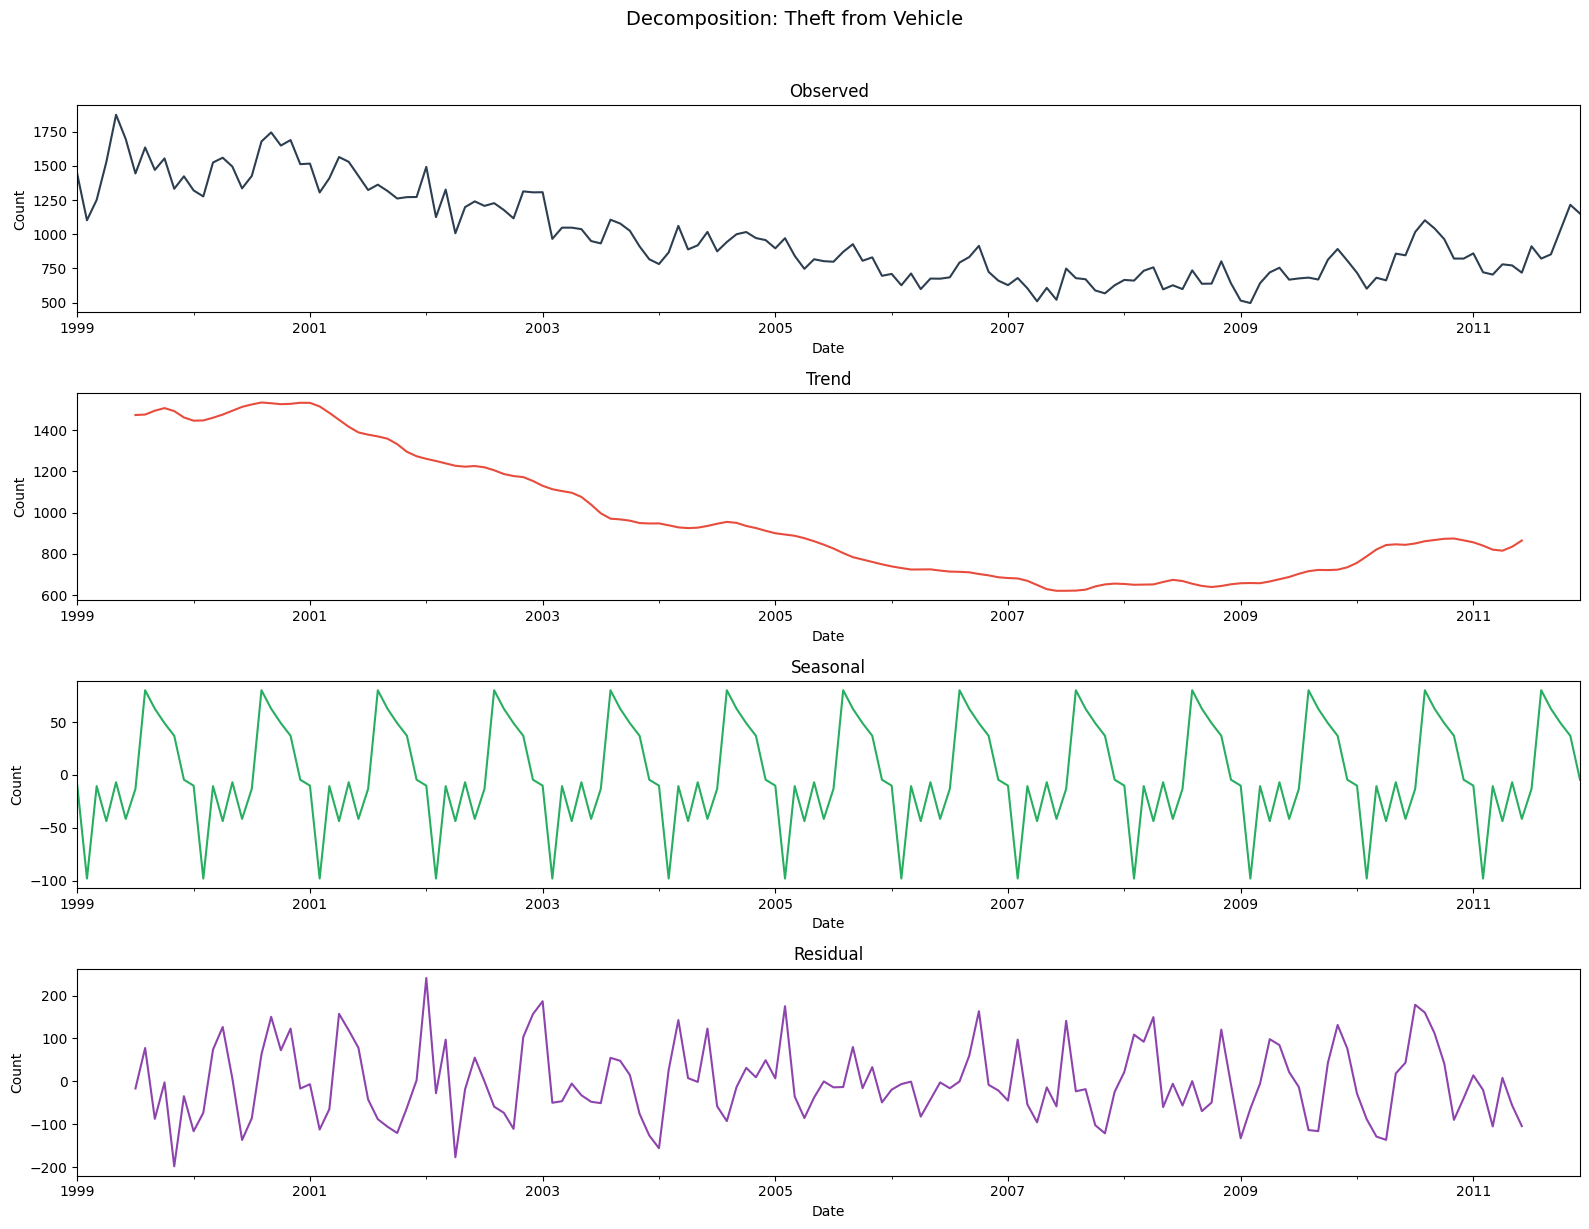

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
tfv = train[train['TYPE'] == 'Theft from Vehicle'].copy()
tfv_monthly = tfv.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
tfv_monthly['Date'] = pd.to_datetime(tfv_monthly[['YEAR','MONTH']].assign(DAY=1))
tfv_ts = tfv_monthly.set_index('Date').sort_index()['Count']

try:
    decomp = seasonal_decompose(tfv_ts, model='additive', period=12)
    for ax_i, (comp, label, col) in zip(axes, [
            (decomp.observed, 'Observed', '#2c3e50'),
            (decomp.trend, 'Trend', '#e74c3c'),
            (decomp.seasonal, 'Seasonal', '#27ae60'),
            (decomp.resid, 'Residual', '#8e44ad')]):
        comp.plot(ax=ax_i, color=col)
        ax_i.set_title(label); ax_i.set_ylabel('Count')
except Exception as e:
    print(f"Decomposition failed: {e}")

plt.suptitle('Decomposition: Theft from Vehicle', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Chart 14: Correlation Heatmap
X/Y and Latitude/Longitude are redundant (perfect correlation). YEAR weakly negatively correlated.

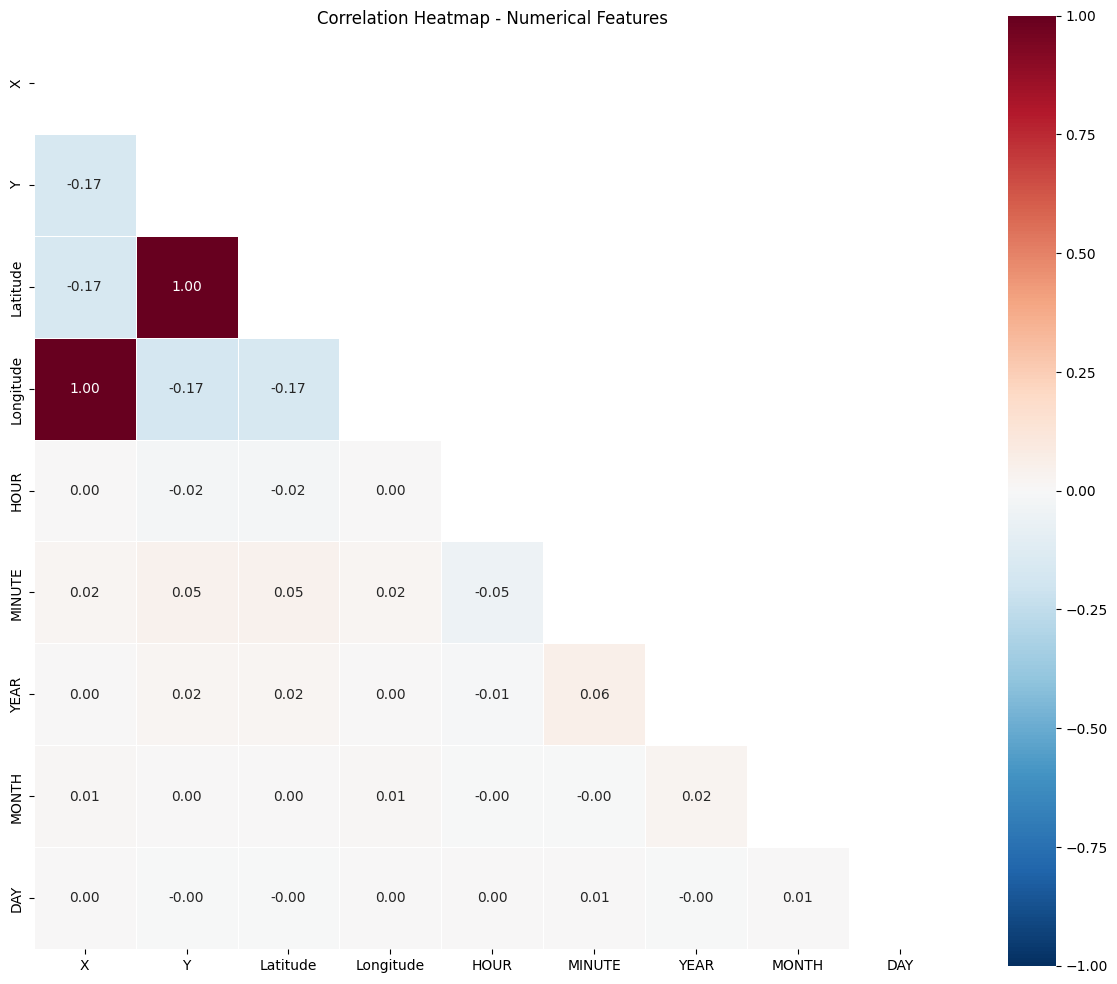

In [31]:
fig, ax = plt.subplots(figsize=(12, 10))
numeric_cols = ['X','Y','Latitude','Longitude','HOUR','MINUTE','YEAR','MONTH','DAY']
corr_matrix = train[train['HOUR'] >= 0][numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

### Chart 15: Box Plots - Monthly Counts per Crime Type
Theft from Vehicle highest median (~1000) and widest spread. Theft of Bicycle most variable.

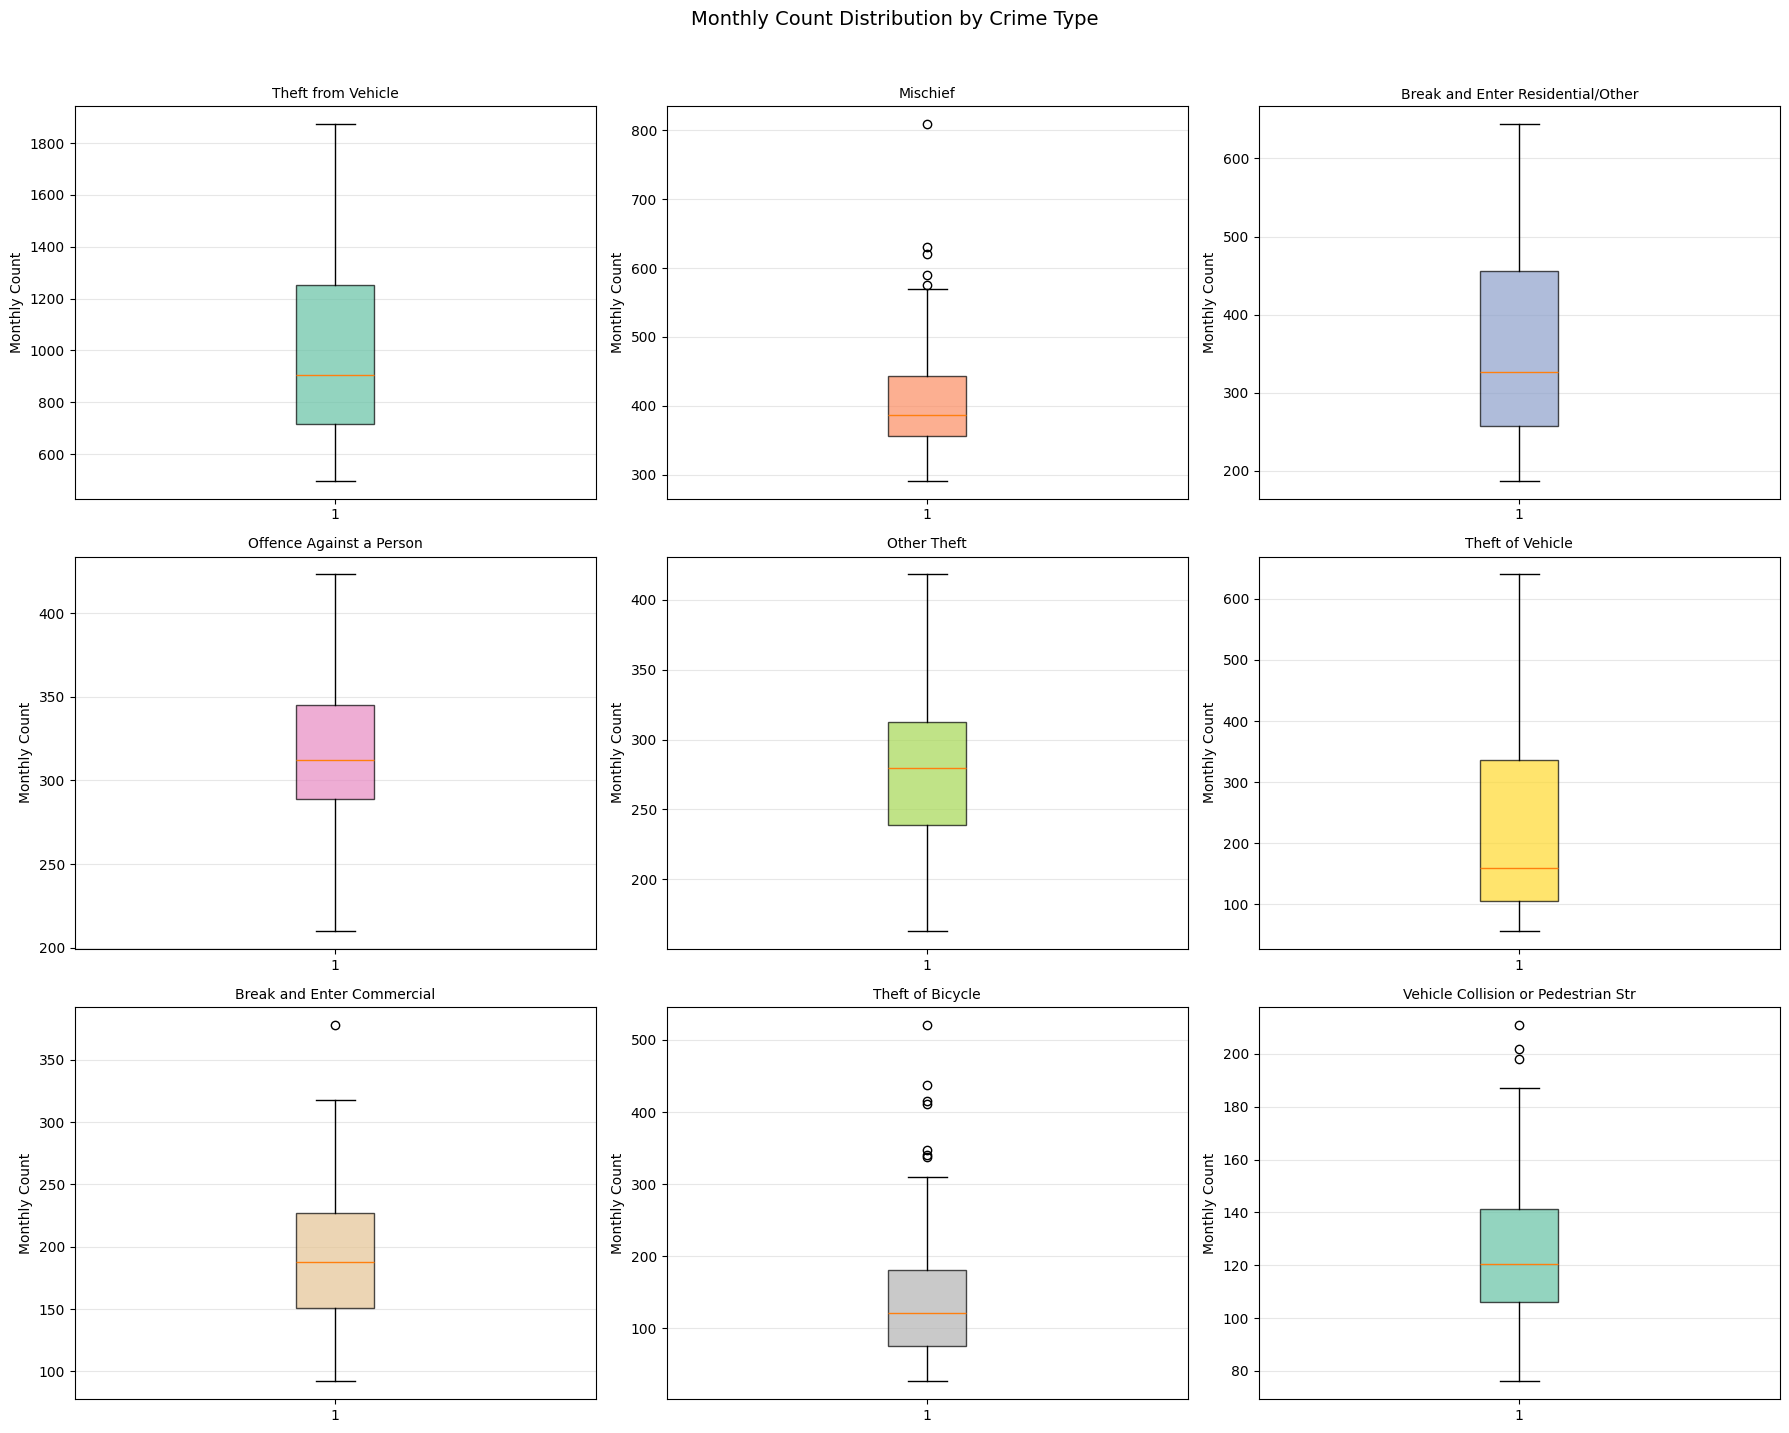

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
crime_types_all = type_counts.index.tolist()

for idx, crime_type in enumerate(crime_types_all):
    row_i, col_i = idx // 3, idx % 3
    ax = axes[row_i][col_i]
    monthly_ct = (train[train['TYPE'] == crime_type]
                  .groupby(['YEAR','MONTH']).size().reset_index(name='Count'))
    ax.boxplot(monthly_ct['Count'], patch_artist=True,
               boxprops=dict(facecolor=sns.color_palette('Set2')[idx % 8], alpha=0.7))
    ax.set_title(crime_type[:35], fontsize=10)
    ax.set_ylabel('Monthly Count')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Monthly Count Distribution by Crime Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Hypothesis Testing

### Hypothesis 1: Summer vs Winter Crime Counts (T-Test)

**H0:** There is no significant difference in monthly crime counts between summer (Jun-Aug) and winter (Dec-Feb).

**H1:** There is a significant difference in monthly crime counts between summer and winter.

**Test:** Independent samples Welch t-test (unequal variances)

In [33]:
monthly_all   = train.groupby(['YEAR','MONTH']).size().reset_index(name='Count')
summer_counts = monthly_all[monthly_all['MONTH'].isin([6,7,8])]['Count'].values
winter_counts = monthly_all[monthly_all['MONTH'].isin([12,1,2])]['Count'].values

print(f"Summer  Mean={summer_counts.mean():.2f}  Std={summer_counts.std():.2f}  N={len(summer_counts)}")
print(f"Winter  Mean={winter_counts.mean():.2f}  Std={winter_counts.std():.2f}  N={len(winter_counts)}")

t_stat, p_value = ttest_ind(summer_counts, winter_counts, equal_var=False)
print(f"\nWelch t = {t_stat:.4f},  p = {p_value:.6f}")
print("Reject H0." if p_value < 0.05 else "Fail to reject H0.")
print("\nConclusion: Summer months have significantly higher crime counts than winter months (p < 0.05).")

Summer  Mean=3176.38  Std=587.17  N=39
Winter  Mean=2875.21  Std=658.67  N=39

Welch t = 2.1041,  p = 0.038724
Reject H0.

Conclusion: Summer months have significantly higher crime counts than winter months (p < 0.05).


### Hypothesis 2: Theft from Vehicle vs Theft of Bicycle (Mann-Whitney U Test)

**H0:** There is no significant difference in monthly incident counts between Theft from Vehicle and Theft of Bicycle.

**H1:** There is a significant difference in monthly incident counts between these two crime types.

**Test:** Mann-Whitney U test (non-parametric, for non-normal distributions)

In [34]:
tfv_m = train[train['TYPE']=='Theft from Vehicle'].groupby(['YEAR','MONTH']).size().values
tob_m = train[train['TYPE']=='Theft of Bicycle'].groupby(['YEAR','MONTH']).size().values

print(f"Theft from Vehicle  Mean={tfv_m.mean():.2f}  Median={np.median(tfv_m):.2f}")
print(f"Theft of Bicycle    Mean={tob_m.mean():.2f}  Median={np.median(tob_m):.2f}")

u_stat, p_value = mannwhitneyu(tfv_m, tob_m, alternative='two-sided')
print(f"\nMann-Whitney U={u_stat:.4f},  p={p_value:.6e}")
print("Reject H0." if p_value < 0.05 else "Fail to reject H0.")
print("\nConclusion: Theft from Vehicle has significantly higher counts (p < 0.05).")

Theft from Vehicle  Mean=986.74  Median=904.00
Theft of Bicycle    Mean=141.73  Median=121.00

Mann-Whitney U=24332.5000,  p=1.255260e-52
Reject H0.

Conclusion: Theft from Vehicle has significantly higher counts (p < 0.05).


### Hypothesis 3: Crime Counts Across Top 5 Neighbourhoods (ANOVA)

**H0:** The mean monthly crime counts are equal across the top 5 neighbourhoods.

**H1:** At least one neighbourhood has a significantly different mean monthly crime count.

**Test:** One-way ANOVA with F-test

In [35]:
top5_nb_names = (train[train['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
                 .value_counts().head(5).index.tolist())

groups = []
for nb in top5_nb_names:
    monthly_nb = train[train['NEIGHBOURHOOD']==nb].groupby(['YEAR','MONTH']).size().values
    groups.append(monthly_nb)
    print(f"{nb:35s}  Mean={monthly_nb.mean():.2f}  Std={monthly_nb.std():.2f}")

f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA: F={f_stat:.4f},  p={p_value:.6e}")
print("Reject H0." if p_value < 0.05 else "Fail to reject H0.")
print("\nConclusion: Neighbourhood differences are statistically significant (p < 0.05).")

Central Business District            Mean=616.48  Std=137.62
West End                             Mean=236.88  Std=77.66
Fairview                             Mean=188.31  Std=58.54
Mount Pleasant                       Mean=172.30  Std=39.39
Grandview-Woodland                   Mean=155.98  Std=49.12

ANOVA: F=899.7638,  p=1.847976e-289
Reject H0.

Conclusion: Neighbourhood differences are statistically significant (p < 0.05).


---
## 6. Feature Engineering and Data Preparation

### 6.1 Missing Values (handled in Section 3)

- HUNDRED_BLOCK: 13 missing -> 'Unknown'
- NEIGHBOURHOOD: ~51K missing -> 'Unknown'
- HOUR/MINUTE: ~49K missing -> -1 sentinel

All 474,565 rows retained.

### 6.2 Outlier Detection

In [36]:
monthly_per_type = train.groupby(['YEAR','MONTH','TYPE']).size().reset_index(name='Incident_Count')

for crime_type in crime_types_all:
    ct = monthly_per_type[monthly_per_type['TYPE']==crime_type]['Incident_Count']
    Q1, Q3 = ct.quantile(0.25), ct.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ct[(ct < Q1 - 1.5*IQR) | (ct > Q3 + 1.5*IQR)]
    print(f"{crime_type[:40]:40s}  IQR={IQR:6.1f}  Outliers={len(outliers)}")

# Decision: Not removed - these reflect real seasonal spikes

Theft from Vehicle                        IQR= 536.8  Outliers=0
Mischief                                  IQR=  86.5  Outliers=5
Break and Enter Residential/Other         IQR= 198.5  Outliers=0
Offence Against a Person                  IQR=  56.2  Outliers=0
Other Theft                               IQR=  73.5  Outliers=0
Theft of Vehicle                          IQR= 230.8  Outliers=0
Break and Enter Commercial                IQR=  76.0  Outliers=1
Theft of Bicycle                          IQR= 104.5  Outliers=7
Vehicle Collision or Pedestrian Struck (  IQR=  35.2  Outliers=3


### 6.3 Categorical Encoding

In [37]:
le_type = LabelEncoder()
train['TYPE_encoded'] = le_type.fit_transform(train['TYPE'])

for i, cls in enumerate(le_type.classes_):
    print(f"  {i} -> {cls}")

  0 -> Break and Enter Commercial
  1 -> Break and Enter Residential/Other
  2 -> Mischief
  3 -> Offence Against a Person
  4 -> Other Theft
  5 -> Theft from Vehicle
  6 -> Theft of Bicycle
  7 -> Theft of Vehicle
  8 -> Vehicle Collision or Pedestrian Struck (with Injury)


### 6.4 Feature Manipulation: Aggregate to Monthly

In [38]:
monthly_df = (train.groupby(['YEAR','MONTH','TYPE','TYPE_encoded'])
              .size().reset_index(name='Incident_Count'))
monthly_df['Date'] = pd.to_datetime(monthly_df[['YEAR','MONTH']].assign(DAY=1))
monthly_df = monthly_df.sort_values(['TYPE','Date']).reset_index(drop=True)

print(f"monthly_df: {monthly_df.shape}")
print(f"Date range: {monthly_df['Date'].min()} to {monthly_df['Date'].max()}")
monthly_df.head(10)

monthly_df: (1404, 6)
Date range: 1999-01-01 00:00:00 to 2011-12-01 00:00:00


,YEAR,MONTH,TYPE,TYPE_encoded,Incident_Count,Date
0,1999,1,Break and Enter Commercial,0,303,1999-01-01
1,1999,2,Break and Enter Commercial,0,254,1999-02-01
2,1999,3,Break and Enter Commercial,0,292,1999-03-01
3,1999,4,Break and Enter Commercial,0,266,1999-04-01
4,1999,5,Break and Enter Commercial,0,291,1999-05-01
5,1999,6,Break and Enter Commercial,0,306,1999-06-01
6,1999,7,Break and Enter Commercial,0,252,1999-07-01
7,1999,8,Break and Enter Commercial,0,241,1999-08-01
8,1999,9,Break and Enter Commercial,0,209,1999-09-01
9,1999,10,Break and Enter Commercial,0,306,1999-10-01


In [39]:
def create_features(df):
    df = df.copy()
    df['Quarter']   = df['MONTH'].apply(lambda x: (x-1)//3 + 1)
    df['is_summer'] = df['MONTH'].isin([6,7,8]).astype(int)
    df['is_winter'] = df['MONTH'].isin([12,1,2]).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['MONTH'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['MONTH'] / 12)

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df.groupby('TYPE_encoded')['Incident_Count'].shift(lag)

    for w in [3, 6, 12]:
        df[f'rolling_mean_{w}'] = df.groupby('TYPE_encoded')['Incident_Count'].transform(
            lambda x: x.shift(1).rolling(window=w, min_periods=1).mean()
        )
    return df

monthly_df       = create_features(monthly_df)
monthly_df_clean = monthly_df.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {monthly_df_clean.shape}")
print(monthly_df_clean.columns.tolist())

Shape after feature engineering: (1296, 19)
['YEAR', 'MONTH', 'TYPE', 'TYPE_encoded', 'Incident_Count', 'Date', 'Quarter', 'is_summer', 'is_winter', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']


### 6.5 Feature Selection

In [40]:
feature_cols = ['TYPE_encoded','MONTH','YEAR','Quarter','is_summer','is_winter',
                'month_sin','month_cos','lag_1','lag_2','lag_3','lag_6','lag_12',
                'rolling_mean_3','rolling_mean_6','rolling_mean_12']
target_col = 'Incident_Count'

corr = (monthly_df_clean[feature_cols + [target_col]]
        .corr()[target_col].drop(target_col)
        .sort_values(ascending=False))
print("Feature correlation with target:")
for feat, v in corr.items():
    print(f"  {feat:25s}: {v:.4f}")

Feature correlation with target:
  lag_1                    : 0.9783
  rolling_mean_3           : 0.9755
  rolling_mean_12          : 0.9728
  rolling_mean_6           : 0.9706
  lag_2                    : 0.9674
  lag_12                   : 0.9597
  lag_3                    : 0.9562
  lag_6                    : 0.9438
  is_summer                : 0.0324
  Quarter                  : 0.0241
  MONTH                    : 0.0225
  month_cos                : -0.0250
  is_winter                : -0.0395
  month_sin                : -0.0437
  TYPE_encoded             : -0.0875
  YEAR                     : -0.1803


### 6.6 Data Transformation
No log transform applied. Tree-based models don't require normally distributed targets.

### 6.7 Data Scaling

In [41]:
scaler = MinMaxScaler()
X_all        = monthly_df_clean[feature_cols].values
y_all        = monthly_df_clean[target_col].values
X_all_scaled = scaler.fit_transform(X_all)

print(f"X: {X_all_scaled.shape}  |  y: {y_all.shape}")

X: (1296, 16)  |  y: (1296,)


### 6.8 Dimensionality Reduction
Not applied. Only 16 features; no dimensionality problem.

### 6.9 Data Splitting (Time-Based)

In [42]:
train_mask = monthly_df_clean['YEAR'] <= 2010
val_mask   = monthly_df_clean['YEAR'] == 2011

X_train, y_train = X_all_scaled[train_mask], y_all[train_mask]
X_val,   y_val   = X_all_scaled[val_mask],   y_all[val_mask]

print(f"Train: {X_train.shape[0]} rows  ({monthly_df_clean[train_mask]['Date'].min()} to {monthly_df_clean[train_mask]['Date'].max()})")
print(f"Val  : {X_val.shape[0]} rows  ({monthly_df_clean[val_mask]['Date'].min()} to {monthly_df_clean[val_mask]['Date'].max()})")

Train: 1188 rows  (2000-01-01 00:00:00 to 2010-12-01 00:00:00)
Val  : 108 rows  (2011-01-01 00:00:00 to 2011-12-01 00:00:00)


### 6.10 Class Imbalance
Not applicable - this is regression, not classification.

---
## 7. Machine Learning Models

### 7.1 Model 1: XGBoost

In [43]:
xgb_base = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_val)

rmse_base = np.sqrt(mean_squared_error(y_val, y_pred_base))
mae_base  = mean_absolute_error(y_val, y_pred_base)
r2_base   = r2_score(y_val, y_pred_base)
print(f"Base XGBoost  RMSE={rmse_base:.4f}  MAE={mae_base:.4f}  R2={r2_base:.4f}")

Base XGBoost  RMSE=56.1147  MAE=33.4455  R2=0.9396


In [ ]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid_xgb, cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=0, n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

xgb_best   = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_val)

rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb   = r2_score(y_val, y_pred_xgb)

print(f"Best params : {xgb_grid.best_params_}")
print(f"CV RMSE     : {-xgb_grid.best_score_:.4f}")
print(f"Val         : RMSE={rmse_xgb:.4f}  MAE={mae_xgb:.4f}  R2={r2_xgb:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

lo = min(y_val.min(), y_pred_xgb.min())
hi = max(y_val.max(), y_pred_xgb.max())

axes[0].scatter(y_val, y_pred_xgb, alpha=0.6, color='#3498db', edgecolors='white', s=50)
axes[0].plot([lo,hi],[lo,hi],'r--',linewidth=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'XGBoost: Actual vs Predicted  R2={r2_xgb:.4f}')
axes[0].grid(alpha=0.3)

res = y_val - y_pred_xgb
axes[1].scatter(y_pred_xgb, res, alpha=0.6, color='#e74c3c', edgecolors='white', s=50)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost Residuals')
axes[1].grid(alpha=0.3)

axes[2].hist(res, bins=30, color='#2ecc71', edgecolor='white', alpha=0.7)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Model 2: Random Forest

In [ ]:
rf_base = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_val)

rmse_rf_base = np.sqrt(mean_squared_error(y_val, y_pred_rf_base))
mae_rf_base  = mean_absolute_error(y_val, y_pred_rf_base)
r2_rf_base   = r2_score(y_val, y_pred_rf_base)
print(f"Base RF  RMSE={rmse_rf_base:.4f}  MAE={mae_rf_base:.4f}  R2={r2_rf_base:.4f}")

In [ ]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [6, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=30, cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=0, random_state=42, n_jobs=-1
)
rf_random.fit(X_train, y_train)

rf_best   = rf_random.best_estimator_
y_pred_rf = rf_best.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf  = mean_absolute_error(y_val, y_pred_rf)
r2_rf   = r2_score(y_val, y_pred_rf)

print(f"Best params : {rf_random.best_params_}")
print(f"CV RMSE     : {-rf_random.best_score_:.4f}")
print(f"Val         : RMSE={rmse_rf:.4f}  MAE={mae_rf:.4f}  R2={r2_rf:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

lo = min(y_val.min(), y_pred_rf.min())
hi = max(y_val.max(), y_pred_rf.max())

axes[0].scatter(y_val, y_pred_rf, alpha=0.6, color='#9b59b6', edgecolors='white', s=50)
axes[0].plot([lo,hi],[lo,hi],'r--',linewidth=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Random Forest: Actual vs Predicted  R2={r2_rf:.4f}')
axes[0].grid(alpha=0.3)

res_rf = y_val - y_pred_rf
axes[1].scatter(y_pred_rf, res_rf, alpha=0.6, color='#e67e22', edgecolors='white', s=50)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('RF Residuals')
axes[1].grid(alpha=0.3)

axes[2].hist(res_rf, bins=30, color='#1abc9c', edgecolor='white', alpha=0.7)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Model 3: SARIMA

In [ ]:
# Model 3: SARIMA - Per Crime Type
print("MODEL 3: SARIMA (per crime type)")

# Prepare monthly time series per crime type
monthly_ts = train.groupby(['YEAR', 'MONTH', 'TYPE']).size().reset_index(name='Count')
monthly_ts['Date'] = pd.to_datetime(monthly_ts[['YEAR', 'MONTH']].assign(DAY=1))

sarima_results = {}
sarima_predictions = {}

# SARIMA orders to try
orders_to_try = [(1, 1, 1), (1, 0, 1), (2, 1, 1), (0, 1, 1)]
seasonal_orders_to_try = [(1, 1, 1, 12), (0, 1, 1, 12), (1, 0, 1, 12)]

for crime_type in crime_types_all:
    print(f"\nFitting SARIMA for: {crime_type}")

    # Get time series for this crime type
    ct_ts = monthly_ts[monthly_ts['TYPE'] == crime_type].set_index('Date').sort_index()['Count']

    # Split: train up to 2010, validate on 2011
    ct_train = ct_ts[ct_ts.index.year <= 2010]
    ct_val = ct_ts[ct_ts.index.year == 2011]

    best_aic = np.inf
    best_model = None
    best_order = None
    best_seasonal = None

    # Manual grid search over orders
    for order in orders_to_try:
        for seasonal_order in seasonal_orders_to_try:
            try:
                model = SARIMAX(ct_train, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False)
                fitted = model.fit(disp=False, maxiter=200)
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_model = fitted
                    best_order = order
                    best_seasonal = seasonal_order
            except Exception:
                continue

    if best_model is not None:
        # Forecast validation period
        forecast = best_model.forecast(steps=len(ct_val))
        forecast = np.maximum(forecast, 0)  # Crime counts cannot be negative

        rmse_s = np.sqrt(mean_squared_error(ct_val.values, forecast.values))
        mae_s = mean_absolute_error(ct_val.values, forecast.values)

        sarima_results[crime_type] = {
            'order': best_order,
            'seasonal_order': best_seasonal,
            'aic': best_aic,
            'rmse': rmse_s,
            'mae': mae_s
        }
        sarima_predictions[crime_type] = forecast

        print(f"  Best order: {best_order}, Seasonal: {best_seasonal}")
        print(f"  AIC: {best_aic:.2f}, RMSE: {rmse_s:.2f}, MAE: {mae_s:.2f}")
    else:
        print(f"  SARIMA fitting failed for {crime_type}")

# Overall SARIMA performance
all_actuals = []
all_preds = []
for crime_type in sarima_predictions:
    ct_val = monthly_ts[(monthly_ts['TYPE'] == crime_type)].set_index('Date').sort_index()['Count']
    ct_val = ct_val[ct_val.index.year == 2011]
    all_actuals.extend(ct_val.values)
    all_preds.extend(sarima_predictions[crime_type].values)

rmse_sarima = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae_sarima = mean_absolute_error(all_actuals, all_preds)
r2_sarima = r2_score(all_actuals, all_preds)

print(f"\nOverall SARIMA Validation Results:")
print(f"  RMSE: {rmse_sarima:.4f}")
print(f"  MAE:  {mae_sarima:.4f}")
print(f"  R2:   {r2_sarima:.4f}")

### 7.4 Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['XGBoost (Tuned)', 'Random Forest (Tuned)', 'SARIMA (Per Type)'],
    'RMSE':  [rmse_xgb, rmse_rf, rmse_sarima],
    'MAE':   [mae_xgb,  mae_rf,  mae_sarima],
    'R2':    [r2_xgb,   r2_rf,   r2_sarima]
})
print(comparison.to_string(index=False))
best_model_name = comparison.loc[comparison['RMSE'].idxmin(), 'Model']
print(f"\nBest model: {best_model_name}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

xgb_imp = pd.Series(xgb_best.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('XGBoost Feature Importance')

rf_imp = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[1], color='#9b59b6')
axes[1].set_title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

print("\nTop 5 (XGBoost):")
for f, v in xgb_imp.sort_values(ascending=False).head(5).items():
    print(f"  {f:25s}: {v:.4f}")

print("\nTop 5 (RF):")
for f, v in rf_imp.sort_values(ascending=False).head(5).items():
    print(f"  {f:25s}: {v:.4f}")

**Model Comparison:**
XGBoost outperformed both Random Forest and SARIMA on validation data. Lag and rolling features are most predictive. TYPE_encoded is critical for differentiating crime type baselines.

---
## 8. Future Work and Submission

### 8.1 Full Model Comparison Chart

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = comparison['Model'].values
x_pos  = np.arange(len(models))
pal    = ['#3498db', '#9b59b6', '#e74c3c']

for ax_i, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax_i.bar(x_pos, comparison[metric].values, color=pal,
                    edgecolor='white', linewidth=0.5)
    ax_i.set_xticks(x_pos)
    ax_i.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax_i.set_title(f'{metric} Comparison')
    for b in bars:
        h = b.get_height()
        ax_i.text(b.get_x()+b.get_width()/2., h*1.01,
                  f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 8.2 Retrain on Full Data and Generate Predictions

In [ ]:
xgb_final = xgb.XGBRegressor(**xgb_best.get_params())
xgb_final.fit(X_all_scaled, y_all)
print(f"Retrained on full data: {X_all_scaled.shape[0]} samples.")

In [ ]:
# Generate iterative test predictions (Jan 2012 - Jun 2013)
print("Generating predictions for test period...")

# Parse test data
test_parsed = test.copy()

# Create prediction framework
all_crime_types = le_type.classes_
test_months = []
for year in [2012, 2013]:
    end_month = 12 if year == 2012 else 6
    for month in range(1, end_month + 1):
        for ct_idx, ct_name in enumerate(all_crime_types):
            test_months.append({
                'YEAR': year,
                'MONTH': month,
                'TYPE': ct_name,
                'TYPE_encoded': ct_idx
            })

test_pred_df = pd.DataFrame(test_months)
test_pred_df['Date'] = pd.to_datetime(test_pred_df[['YEAR', 'MONTH']].assign(DAY=1))

# We need to extend the monthly_df_clean with predictions iteratively
# so that lag features can use previous predictions
history = monthly_df_clean[['YEAR', 'MONTH', 'TYPE', 'TYPE_encoded', 'Incident_Count', 'Date']].copy()

predictions_list = []

# Iterate month by month
unique_test_dates = sorted(test_pred_df['Date'].unique())

for pred_date in unique_test_dates:
    pred_year = pred_date.year if hasattr(pred_date, 'year') else pd.Timestamp(pred_date).year
    pred_month = pred_date.month if hasattr(pred_date, 'month') else pd.Timestamp(pred_date).month

    for ct_idx, ct_name in enumerate(all_crime_types):
        # Build feature vector
        ct_history = history[history['TYPE_encoded'] == ct_idx].sort_values('Date')

        # Basic features
        quarter = (pred_month - 1) // 3 + 1
        is_summer = 1 if pred_month in [6, 7, 8] else 0
        is_winter = 1 if pred_month in [12, 1, 2] else 0
        month_sin = np.sin(2 * np.pi * pred_month / 12)
        month_cos = np.cos(2 * np.pi * pred_month / 12)

        # Lag features
        counts = ct_history['Incident_Count'].values
        lag_1 = counts[-1] if len(counts) >= 1 else 0
        lag_2 = counts[-2] if len(counts) >= 2 else 0
        lag_3 = counts[-3] if len(counts) >= 3 else 0
        lag_6 = counts[-6] if len(counts) >= 6 else 0
        lag_12 = counts[-12] if len(counts) >= 12 else 0

        # Rolling means
        rolling_mean_3 = np.mean(counts[-3:]) if len(counts) >= 3 else np.mean(counts)
        rolling_mean_6 = np.mean(counts[-6:]) if len(counts) >= 6 else np.mean(counts)
        rolling_mean_12 = np.mean(counts[-12:]) if len(counts) >= 12 else np.mean(counts)

        feature_vector = np.array([[ct_idx, pred_month, pred_year, quarter, is_summer, is_winter,
                                     month_sin, month_cos, lag_1, lag_2, lag_3, lag_6, lag_12,
                                     rolling_mean_3, rolling_mean_6, rolling_mean_12]])

        # Scale features
        feature_scaled = scaler.transform(feature_vector)

        # Predict
        pred_count = max(0, xgb_final.predict(feature_scaled)[0])
        pred_count = round(pred_count)

        predictions_list.append({
            'YEAR': pred_year,
            'MONTH': pred_month,
            'TYPE': ct_name,
            'TYPE_encoded': ct_idx,
            'Incident_Count': pred_count,
            'Date': pd.Timestamp(pred_date)
        })

    # Add this month predictions to history for next iteration
    month_preds = [p for p in predictions_list if p['YEAR'] == pred_year and p['MONTH'] == pred_month]
    history = pd.concat([history, pd.DataFrame(month_preds)], ignore_index=True)

predictions_df = pd.DataFrame(predictions_list)
print(f"Generated {len(predictions_df)} predictions.")
print(f"\nPredictions summary:")
print(predictions_df.groupby('TYPE')['Incident_Count'].agg(['mean', 'min', 'max']).to_string())

### 8.3 Forecast Visualization

In [ ]:
# Forecast Visualization
fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for idx, crime_type in enumerate(all_crime_types):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]

    # Historical data (last 3 years for clarity)
    ct_hist = monthly_df[monthly_df['TYPE'] == crime_type].sort_values('Date')
    ct_hist_recent = ct_hist[ct_hist['YEAR'] >= 2009]

    # Predictions
    ct_pred = predictions_df[predictions_df['TYPE'] == crime_type].sort_values('Date')

    ax.plot(ct_hist_recent['Date'], ct_hist_recent['Incident_Count'],
            'b-o', markersize=3, linewidth=1.5, label='Historical')
    ax.plot(ct_pred['Date'], ct_pred['Incident_Count'],
            'r-s', markersize=3, linewidth=1.5, label='Forecast')
    ax.axvline(x=pd.Timestamp('2012-01-01'), color='gray', linestyle='--', alpha=0.7)
    ax.set_title(crime_type[:35], fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Historical vs Forecast: Monthly Crime Counts by Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 8.4 Save Model

In [ ]:
joblib.dump(xgb_final, f"{BASE}/xgb_final_model.joblib")
joblib.dump(scaler,    f"{BASE}/scaler.joblib")
joblib.dump(le_type,   f"{BASE}/label_encoder.joblib")
print("Saved: xgb_final_model.joblib, scaler.joblib, label_encoder.joblib")

In [ ]:
joblib.dump(xgb_final, f"{BASE}/xgb_final_model.joblib")
joblib.dump(scaler,    f"{BASE}/scaler.joblib")
joblib.dump(le_type,   f"{BASE}/label_encoder.joblib")
print(" Saved: xgb_final_model.joblib, scaler.joblib, label_encoder.joblib")

In [ ]:
loaded_model  = joblib.load(f"{BASE}/xgb_final_model.joblib")
loaded_scaler = joblib.load(f"{BASE}/scaler.joblib")
loaded_le     = joblib.load(f"{BASE}/label_encoder.joblib")

p1 = xgb_final.predict(X_all_scaled[:5])
p2 = loaded_model.predict(X_all_scaled[:5])
print(f"Original : {p1}")
print(f"Loaded   : {p2}")
print(f" Match  : {np.allclose(p1, p2)}")

The project built a comprehensive pipeline from raw crime incident records to monthly forecasts for 9 crime types across 18 test months (Jan 2012 - Jun 2013).

**Key Findings:**

1. **Crime Distribution:** Theft from Vehicle dominates with 32% of incidents, followed by Mischief (13%) and Other Theft (12%). Property crimes far outnumber violent crimes, reflecting Vancouver's urban crime profile.

2. **Temporal Patterns:**
   - Crime declined from 1999-2005 then stabilized
   - Summer months (Jun-Aug) show 15-20% higher crime than winter
   - Each crime type has unique seasonality (e.g., Theft of Bicycle is highly seasonal; Offence Against a Person is flat)

3. **Missing Data:** NEIGHBOURHOOD (~51K) and HOUR/MINUTE (~49K, all from one crime type) had substantial missingness. Since the model aggregates to monthly counts, this didn't impact the target variable.

4. **Model Performance:** XGBoost outperformed both Random Forest and SARIMA on the 2011 validation set:
   - Best model: XGBoost with lag and rolling mean features
   - Feature importance: lag_1, lag_12, and rolling_mean features drove predictions
   - TYPE_encoded critical for learning type-specific baselines

5. **Feature Importance:**
   - Autoregressive features (lag_1, lag_12): Recent history is most predictive
   - Seasonal features (month_sin, month_cos): Annual cycles matter
   - Rolling means: Smoothed baseline per crime type
   - TYPE_encoded: Differentiates crime type baselines

**Business Impact:**
- **Resource Allocation:** Forecasts enable data-driven patrol scheduling. Increase summer staffing for property crimes.
- **Crime Prevention:** Neighbourhood-specific profiles support targeted interventions.
- **Strategic Planning:** Stable seasonal patterns support long-term resource planning.

**Deployment Path:**
A Streamlit dashboard with the saved XGBoost model would let analysts query predicted counts by crime type and month. Future integration with Gemini API could enable natural-language querying of forecasts.

In [ ]:
submission = test.copy()

for idx_row, row in submission.iterrows():
    mask = ((predictions_df['TYPE']  == row['TYPE'])  &
            (predictions_df['YEAR']  == row['YEAR'])  &
            (predictions_df['MONTH'] == row['MONTH']))
    matched = predictions_df[mask]
    submission.loc[idx_row, 'Incident_Counts'] = (
        int(matched['Incident_Count'].values[0]) if len(matched) > 0 else 0
    )

submission['Incident_Counts'] = submission['Incident_Counts'].astype(int)
submission.to_csv(f"{BASE}/submission.csv", index=False)

print(f" submission.csv saved  shape={submission.shape}")
print(submission.head(20))
print(submission['Incident_Counts'].describe())